In [1]:
%load_ext autoreload
%autoreload 2
# %matplotlib ipympl
%config InlineBackend.figure_format='retina'

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch

import sys
sys.path.append('../factorised-MA-AIF/')

from games import *
# from agent import Agent
from network_agent import NetworkAgent
import utils.simulation

INFO:numexpr.utils:NumExpr defaulting to 10 threads.


## Network and games definition

In [2]:
available_games = {
    'Ch': chicken_2player, 
    # 'PD': prisoners_dilemma_2player, 
    'SH': stag_hunt_2player, 
    # 'Ha': harmony_2player
}

def get_game_name(this_game, available_games):
    for key, game in available_games.items():
        if torch.equal(this_game, game):
            return key
    return None

Simulation: n=10 agents playing 20 games


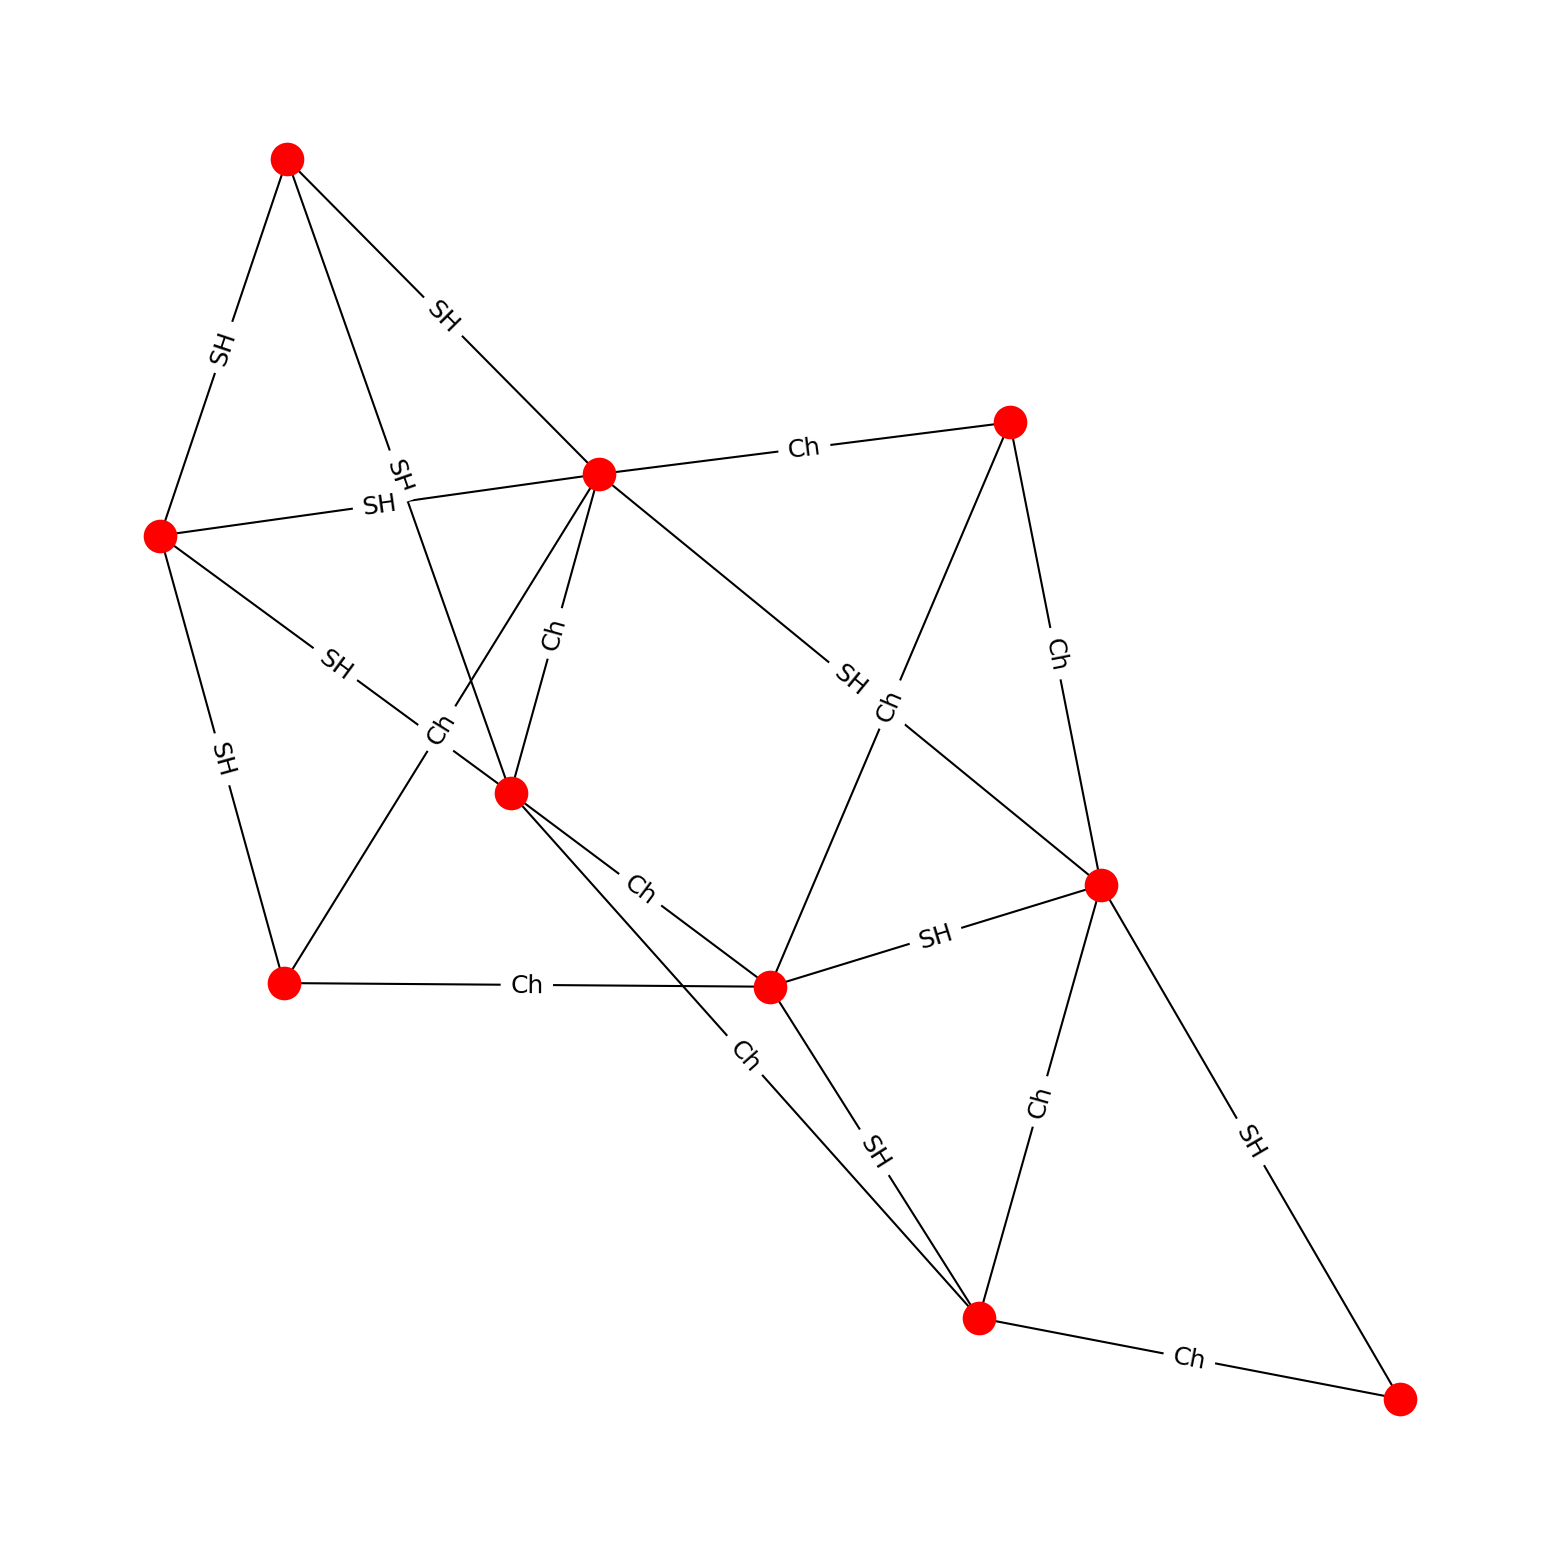

In [6]:
# Predefined constants
n = 10  # Number of nodes
p = 0.9 # Probability of edge reconnection
l = 4  # Number of edges per node

# Generate an Erdős-Rényi network
G = nx.watts_strogatz_graph(n, l, p)

# Assign a random game to each edge in the graph
for edge in G.edges:
    G.edges[edge]['game'] = list(available_games.values())[np.random.randint(len(available_games))]

# List the edges and their corresponding games
print(f"Simulation: n={G.number_of_nodes()} agents playing {G.number_of_edges()} games")
for edge in G.edges(data=True):
    game = edge[2]['game']
    game_name = get_game_name(game, available_games)
    # print(f"{edge[:2]} -- {game_name}")

# Plot the network
plt.figure(figsize=(5, 5), dpi=150)
pos = nx.spring_layout(G)
nx.draw(
    G, 
    pos, 
    with_labels=False, 
    node_size=50, 
    node_color='red', 
    edge_color='black', 
    width=0.5
)
edge_labels = {(edge[0], edge[1]): get_game_name(edge[2]['game'], available_games) for edge in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
plt.show()

## AIF agents simulation

In [7]:
T = 500
num_players = len(G.nodes)  # Number of players (nodes in the graph)

agent_kwargs = [                                                                # <--- Define agent configurations here
    dict(
        beta_1=200.,
        dynamic_precision=True,
        decay=0.9,
        # A_learning=False,
        learn_every_t_steps=10,
        learning_offset=8,
    )
] * num_players

# Initialisation ---------------------------------------------------------------
agents = []
for node in G.nodes:
    adjacent_games = [G.edges[edge]['game'] for edge in G.edges(node)]
    agents.append(
        NetworkAgent(
            id=node, 
            game_matrices=adjacent_games, 
            **agent_kwargs[node]
        )
    )

# Instantiate the simulator object
ig = utils.simulation.IteratedNetworkGame(agents=agents, network=G, seed=None)

# Simulation -------------------------------------------------------------------
variables_history = ig.run(T)

INFO:root:Simulation started with seed 81
Simulation progress: 100%|██████████| 500/500 [00:56<00:00,  8.84steps/s]


## Plotting

Text(0, 0.5, 'q_u')

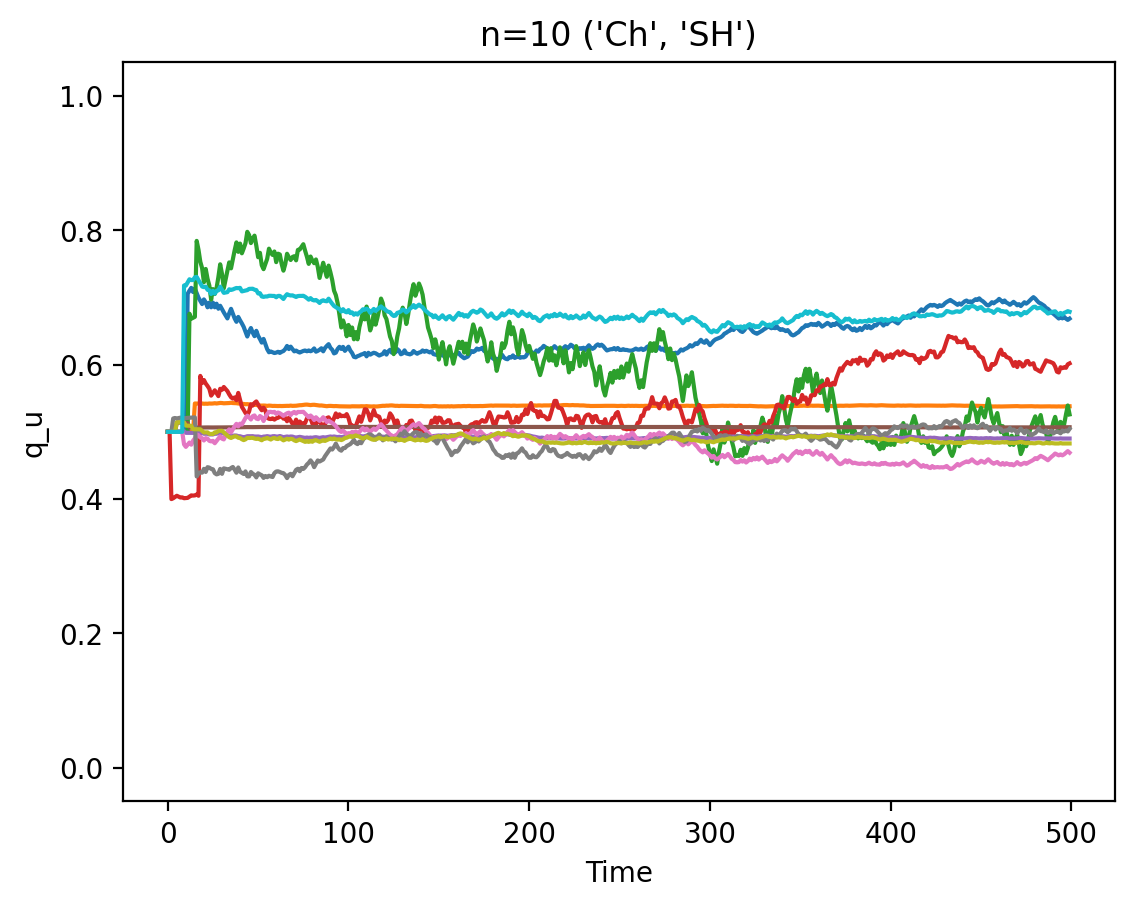

In [8]:
MARGIN = 0.05
q_u_history = np.array(variables_history['q_u'])
for i in range(num_players):
    plt.plot(q_u_history[:, i, 0], label='Agent 0')  # indices: time, agent, action
plt.ylim(0-MARGIN, 1+MARGIN)
plt.title(f'n={len(G.nodes)} {tuple(available_games.keys())}')
plt.xlabel('Time')
plt.ylabel('q_u')

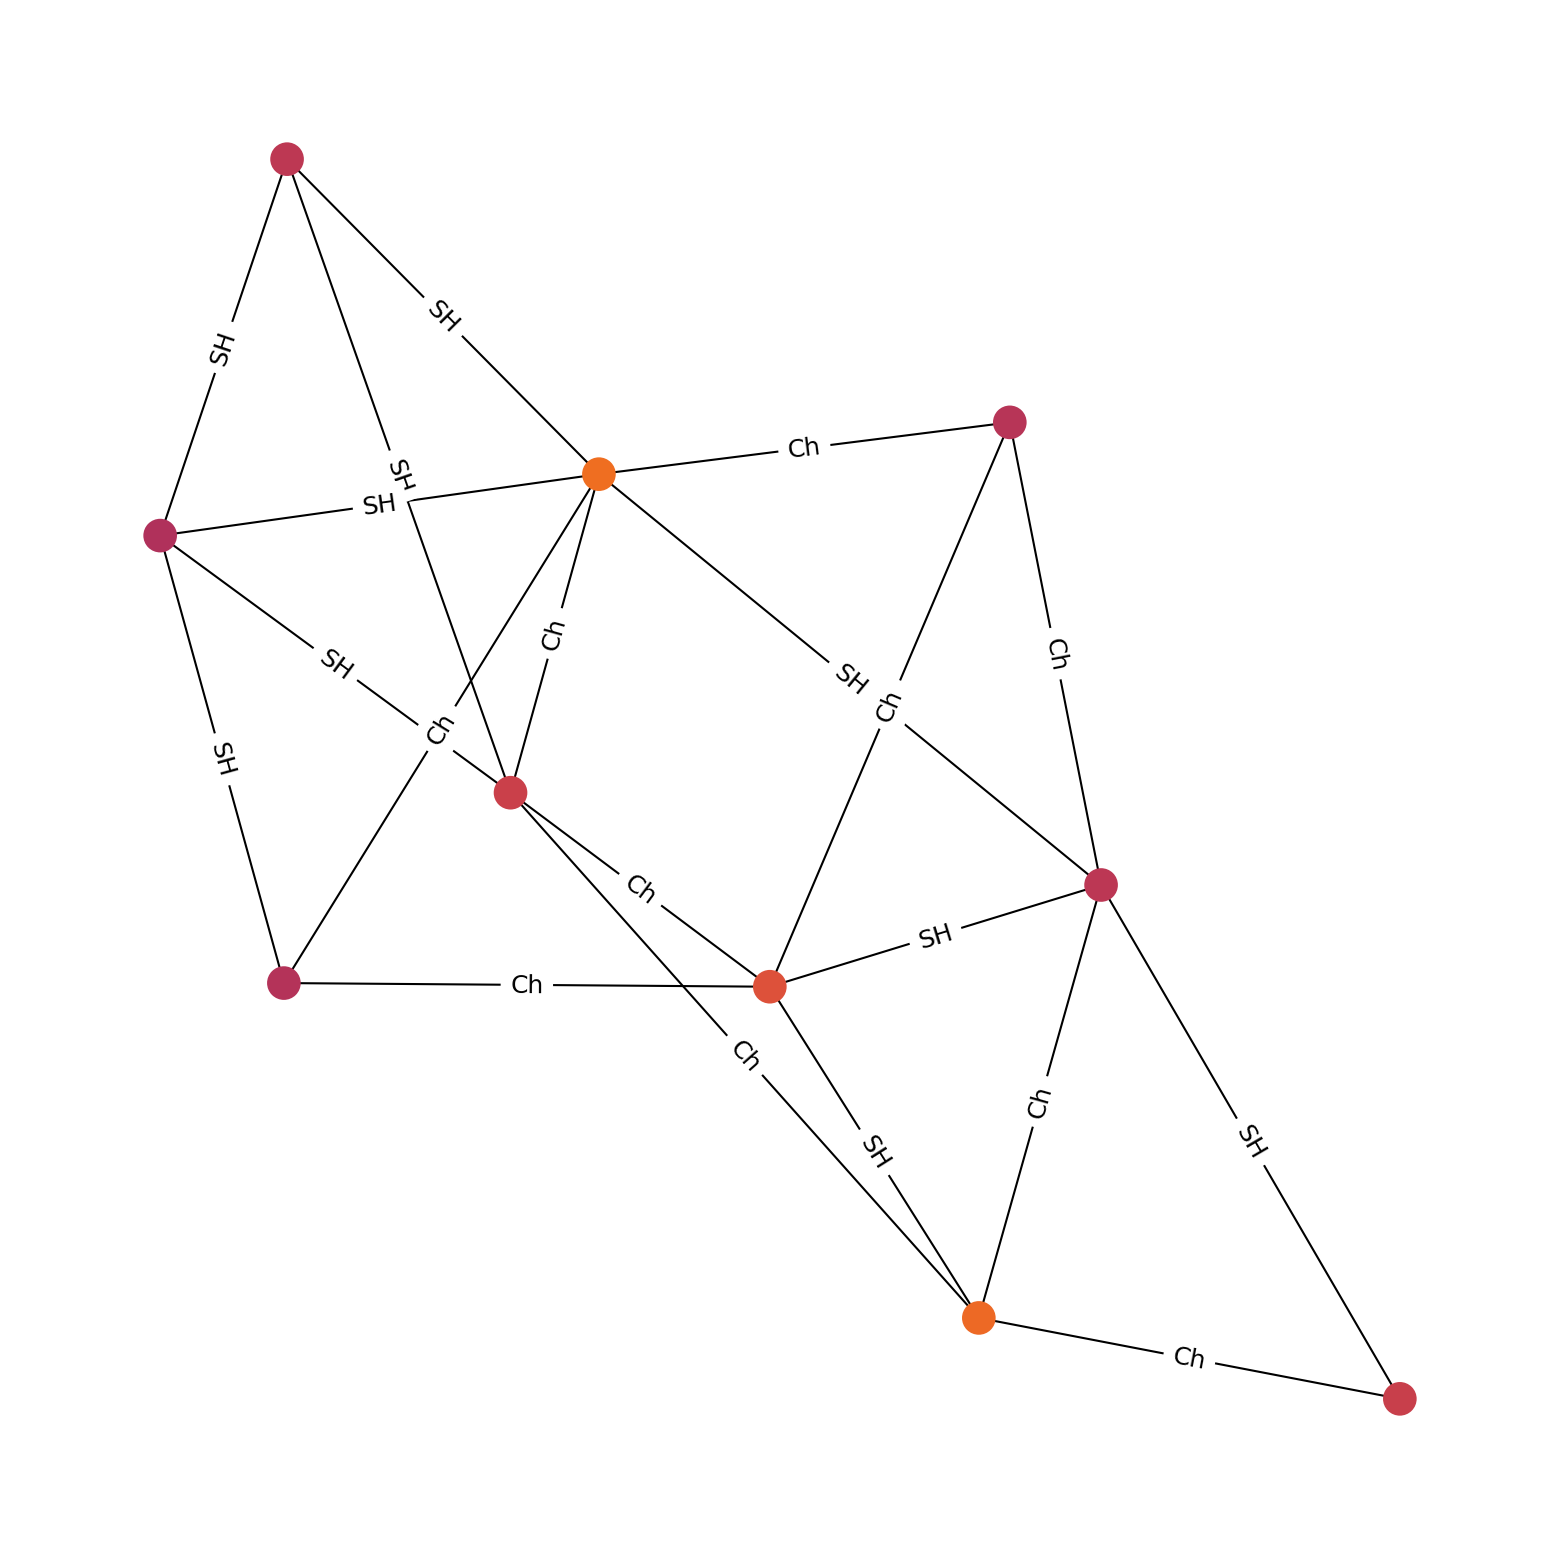

In [9]:
node_intensity = q_u_history[-2, :, 0]  # Extract node intensities
plt.figure(figsize=(5, 5), dpi=150)
nx.draw(
    G, 
    pos, 
    with_labels=False, 
    node_size=50, 
    node_color=node_intensity, 
    vmin=0, 
    vmax=1, 
    edge_color='black', 
    cmap=plt.cm.inferno,
    width=0.5
)
edge_labels = {(edge[0], edge[1]): get_game_name(edge[2]['game'], available_games) for edge in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
plt.show()

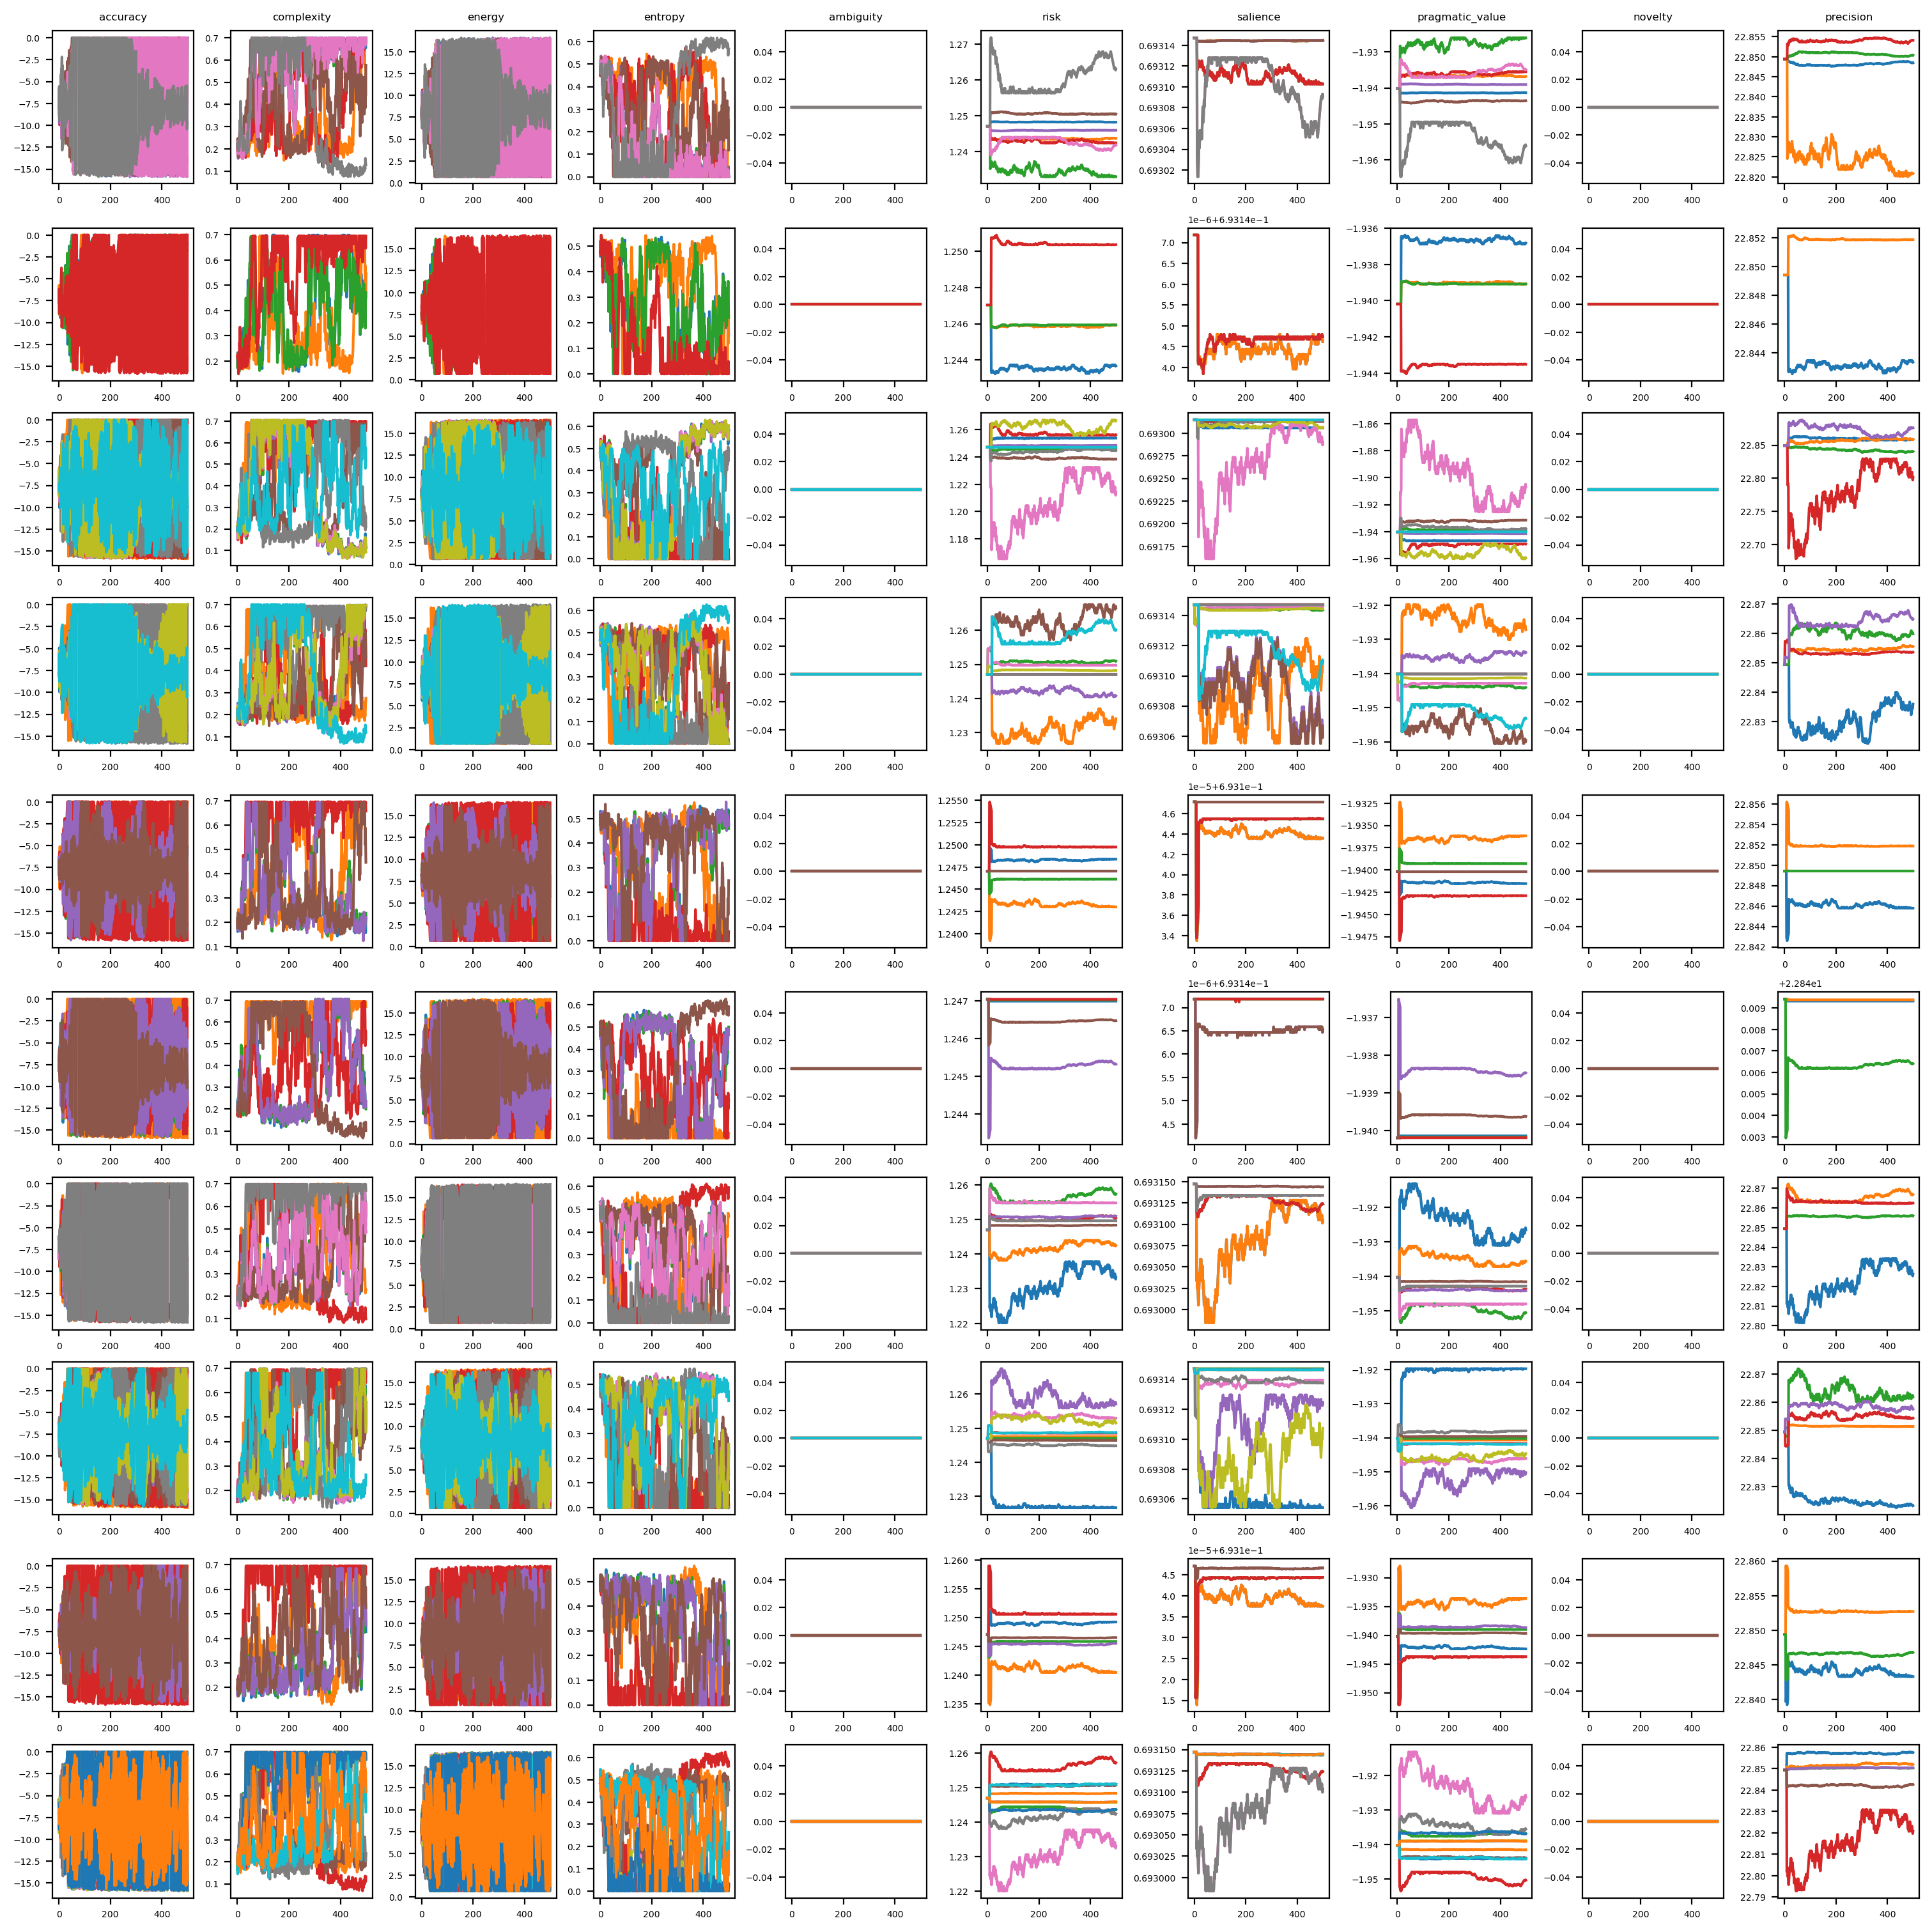

In [10]:
variable_names = list(variables_history['generative_models_data'][0][0][0].keys())
# variable_name = 'complexity'

plt.rc('font', size=5)
fig, axs = plt.subplots(
    num_players, 
    len(variable_names), 
    figsize=(15, 15), 
    constrained_layout=True
)
axs = axs.flatten()
for idx, ax in enumerate(axs):
    variable_name = variable_names[idx%len(variable_names)]
    i = idx // len(variable_names)

    data = []
    for t in range(T):
        data.append([
            game[variable_name]
            for game in variables_history['generative_models_data'][t][i]
        ])

    data = np.array(data)

    for j in range(data.shape[1]):
        ax.plot(data[:, j], label=f'Agent {j}')

        if i == 0:  # Add titles to each column
            ax.set_title(variable_name)

## Superagents

In [87]:
# plt.style.use('jrs.mplstyle')

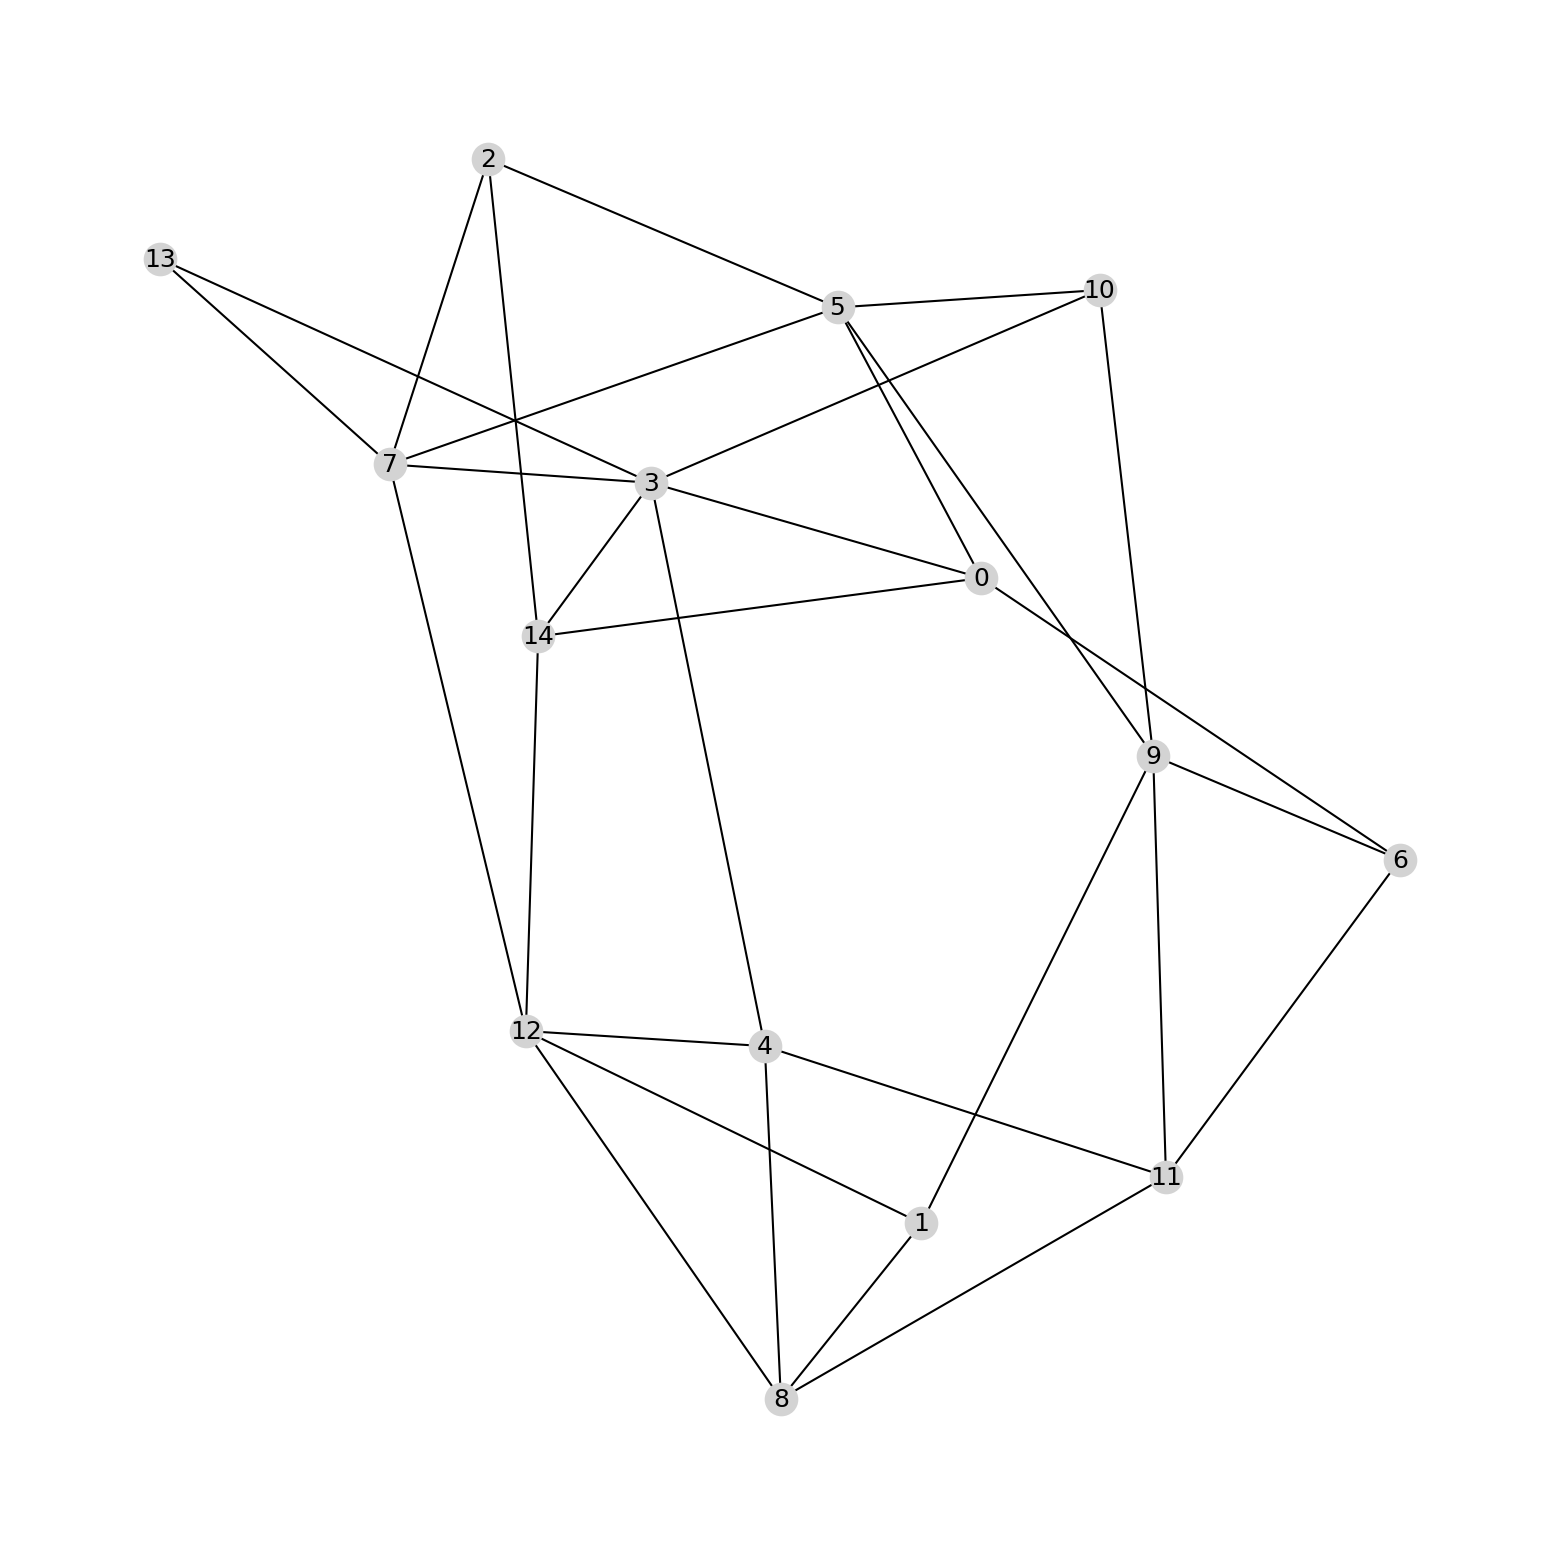

In [88]:
plt.figure(figsize=(5, 5), dpi=150)
nx.draw(
    G, 
    pos, 
    with_labels=False, 
    node_size=50, 
    node_color='lightgrey', 
    vmin=0, 
    vmax=1, 
    edge_color='black', 
    cmap=plt.cm.inferno,
    width=0.5
)
nx.draw_networkx_labels(G, pos, labels={node: str(node) for node in G.nodes()}, font_size=6)
# edge_labels = {(edge[0], edge[1]): get_game_name(edge[2]['game'], available_games) for edge in G.edges(data=True)}
# nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
plt.show()

In [136]:
# nx.single_source_shortest_path_length(G, node, cutoff=2)
i = 10
j = 5
path = nx.shortest_path(G, source=i, target=j)

edges_from_path = [
    tuple(sorted([path[k], path[k + 1]])) 
    for k in range(len(path) - 1)
]
print(f"Edges from path: {edges_from_path}")
print(f"Path from node {i} to node {j}: {path}")

Edges from path: [(2, 10), (2, 5)]
Path from node 10 to node 5: [10, 2, 5]


In [11]:
from itertools import combinations

def remove_duplicates(seq):
    """https://stackoverflow.com/a/480227"""
    seen = set()
    return [x for x in seq if not (x in seen or seen.add(x))]

all_edges_list = list(G.edges)
L_max = 2  # number of hops
superagents = []
superagent_breakdown_list = []
for node in G.nodes:
    # Get all combinations of edges at distance l
    for l in range(1, L_max + 1):
        # Get all neighbors within l hops
        neighbour_distances = nx.single_source_shortest_path_length(G, node, cutoff=l)
        members = neighbour_distances.keys()
    
        subgraph = G.subgraph(members)
        subgraph_edges = list(subgraph.edges)

        combinations_at_distance_l = []
        for superagent_size in range(1, len(members) + 1):
            combinations_at_distance_l += \
                list(combinations(members, superagent_size))
            
        for combination in combinations_at_distance_l:
            candidate = G.subgraph(combination)
            if nx.is_connected(candidate):  # Avoid disconnected superagents
                superagent_edges = sorted(list(candidate.edges))
                superagent_nodes = sorted(list(candidate.nodes))
                if (superagent_nodes, superagent_edges) not in superagent_breakdown_list:
                    superagents.append(candidate)
                    superagent_breakdown_list.append((superagent_nodes, superagent_edges))

len(superagents)

643

In [38]:
superagent_sizes = [len(s) for s in superagents]
len(superagent_sizes)

643

In [39]:
%store superagent_sizes

Stored 'superagent_sizes' (list)


In [277]:
# get_superagent_members = lambda x: sorted(set().union(*x))

# for edge_tuple in superagents[:10]:
#     # Get the list of unique nodes in the edge tuple
#     print(get_superagent_members(edge_tuple))

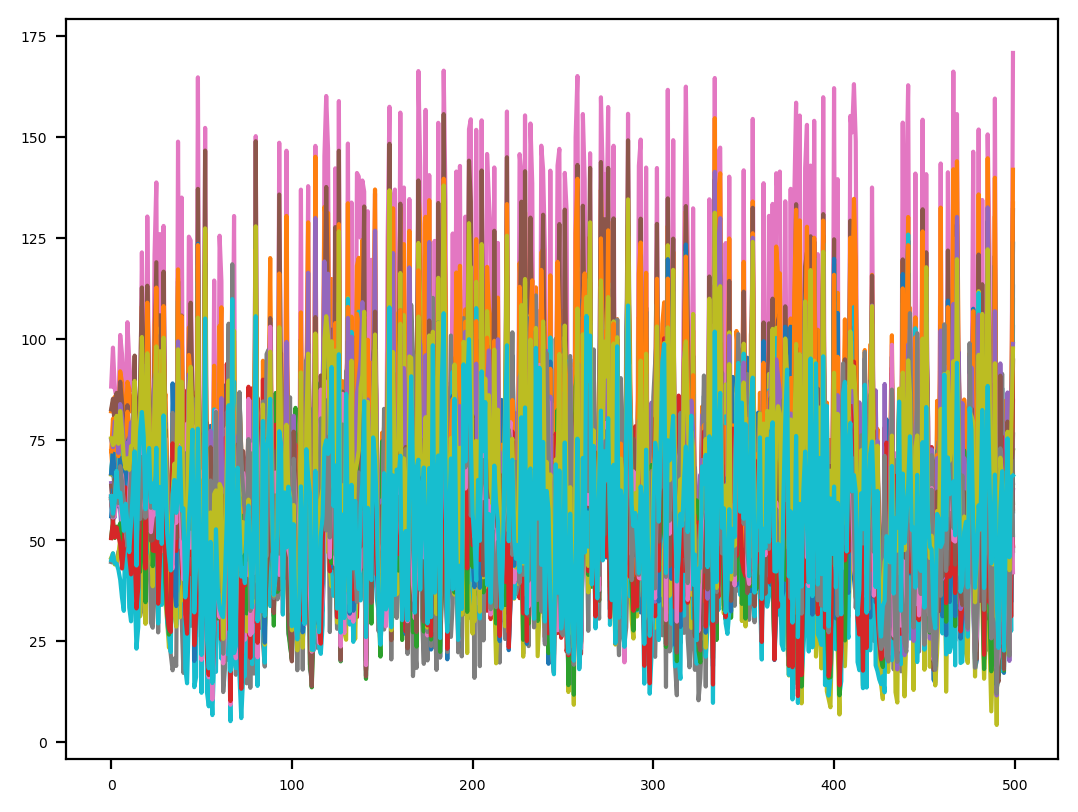

In [14]:
for superagent in superagents[20:50]:
    joint_efe = []
    joint_vfe = []
    for t in range(T):
        joint_vfe.append(0)
        joint_efe.append(0)
        for i in superagent:
            for gm_data in variables_history['generative_models_data'][t][i]:
                joint_vfe[t] += torch.sum(gm_data['complexity'] - gm_data['accuracy']) / len(superagent)
                joint_efe[t] += torch.sum(-gm_data['salience'] -gm_data['pragmatic_value'] -gm_data['novelty']) / len(superagent)
                # print(gm_data['salience'] - gm_data['pragmatic_value'] - gm_data['novelty'])

    plt.plot(joint_vfe)
    # plt.plot(joint_efe)

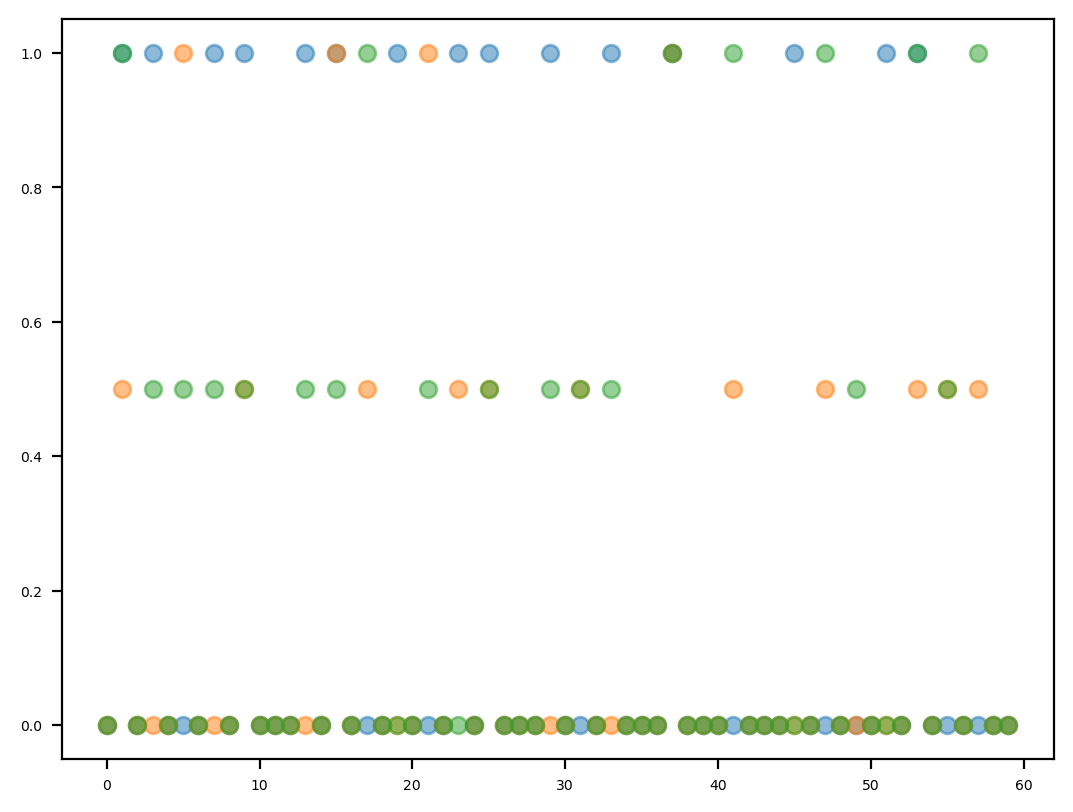

In [15]:
for superagent in superagents[30:33]:
    average_actions = []
    for t in range(50, 80):
        average_actions.append(0)
        value = 0
        for i in superagent:
            value += variables_history['u'][t][i]
        average_actions.append(value/len(superagent))
            
    plt.scatter(np.arange(len(average_actions)), average_actions, alpha=0.5)
    # plt.plot(joint_efe)

In [280]:
# # Check that there are no made up edges in superagents
# edges_list = list(G.edges)
# for edge_tuple in superagents:
#     for edge in edge_tuple:
#         if edge not in edges_list:
#             print(f"Edge {edge} not in graph")

In [16]:
# def get_superagent_graph(G, superagent):
#     # Create a subgraph from the edges in edge_tuple
#     subgraph = G.subgraph(superagent)
#     # Add edges between nodes in get_superagent_members(superagent) to the subgraph
#     # members = get_superagent_members(superagent)
#     additional_edges = [
#         edge for edge in G.edges(superagent) 
#         if edge not in subgraph.edges
#         and edge[0] in superagent 
#         and edge[1] in superagent
#     ]
#     subgraph = G.edge_subgraph(list(subgraph.edges) + additional_edges)
#     return subgraph

def get_environment_and_blanket_graphs(G, superagent_graph):
    # Get the neighbors of the subgraph nodes
    neighbors = set()
    for node in superagent_graph.nodes:
        neighbors.update(G.neighbors(node))
    neighbors.difference_update(superagent_graph.nodes)

    # Create a subgraph for the neighbors and their edges
    neighbor_edges = [(n, nbr) for n in neighbors for nbr in G.neighbors(n) if nbr in superagent_graph.nodes]
    boundary_subgraph = G.edge_subgraph(neighbor_edges)

    environment_nodes = boundary_subgraph.nodes - superagent_graph.nodes
    environment_graph = G.subgraph(environment_nodes)

    blanket_graph = nx.intersection(boundary_subgraph, superagent_graph)

    return environment_graph, blanket_graph, boundary_subgraph

In [28]:
def plot_superagent_graph(
        G, 
        pos, 
        superagent_graph, 
        blanket_graph=None, 
        boundary_subgraph=None,
        title=None,
    ):
    # Plot the subgraph and its neighbors
    plt.figure(figsize=(3, 3), dpi=150)

    # Main graph -----------------------------------------
    nx.draw(
        G, 
        pos, 
        with_labels=False, 
        node_size=30, 
        node_color='lightgray', 
        edge_color='lightgray', 
        width=0.5
    )

    # Blanket --------------------------------------
    if blanket_graph is not None:
        nx.draw(
            blanket_graph,
            {node: pos[node] for node in blanket_graph.nodes},
            with_labels=True,
            node_size=100,
            node_color=(1, 1, 1, 0),
            # edge_color='black',
            width=0.5,
            font_size=6,
            edgecolors='green' 
        )

    # Neighbors --------------------------------------
    if boundary_subgraph is not None:
        nx.draw(
            boundary_subgraph,
            {node: pos[node] for node in boundary_subgraph.nodes},
            with_labels=False,
            node_size=30,
            node_color='blue',
            edge_color='blue',
            width=0.5
        )

    # Superagent --------------------------------------
    nx.draw(
        superagent_graph,
        {node: pos[node] for node in superagent_graph.nodes},
        with_labels=True,
        node_size=30,
        node_color='red',
        edge_color='red',
        width=1.0,
        font_size=6
    )

    if title is None:
        title = f"Superagent {superagent_graph.nodes} (red) and its observable environment (blue)"
    plt.title(title)
    plt.show()

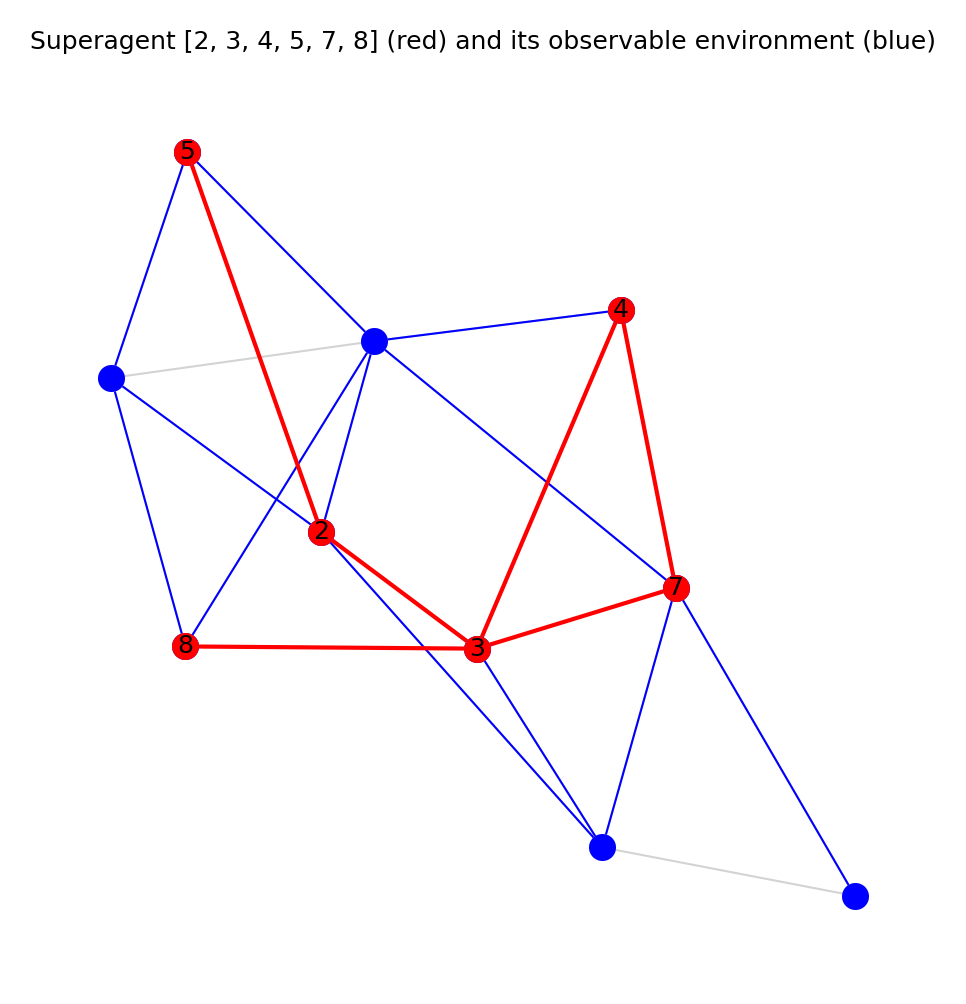

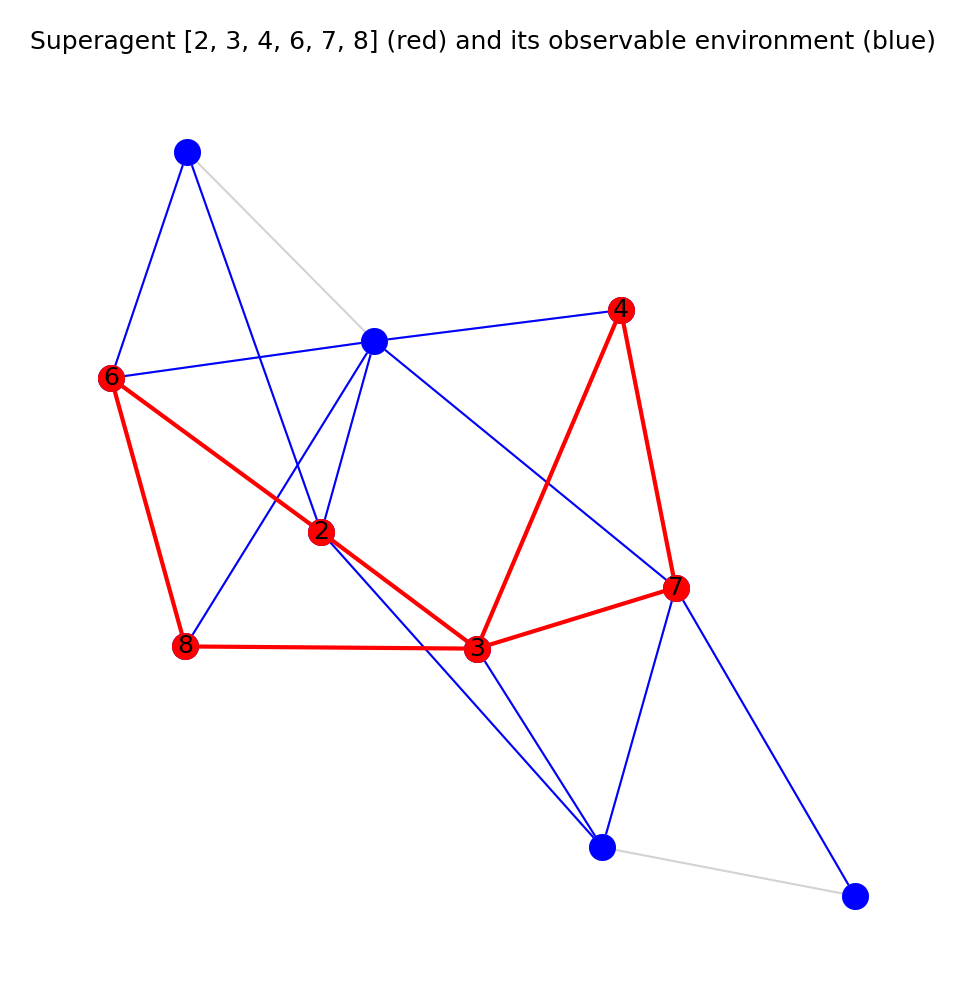

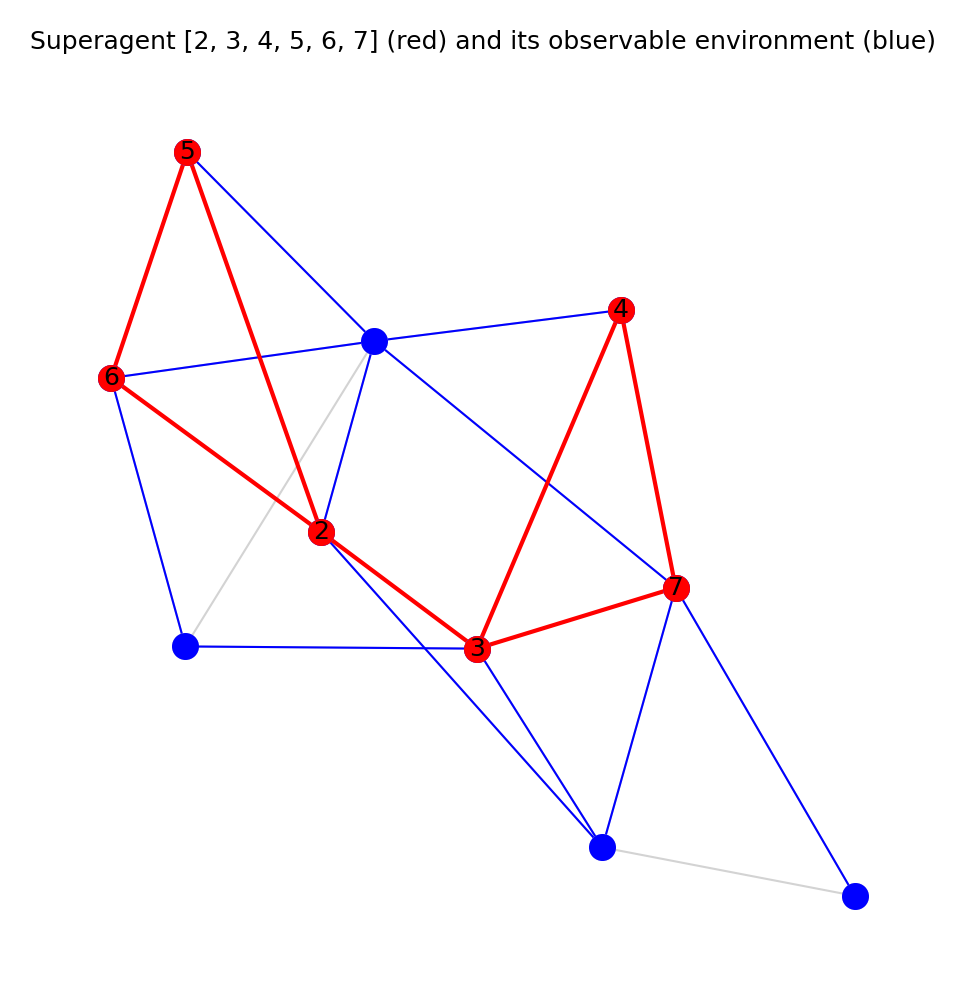

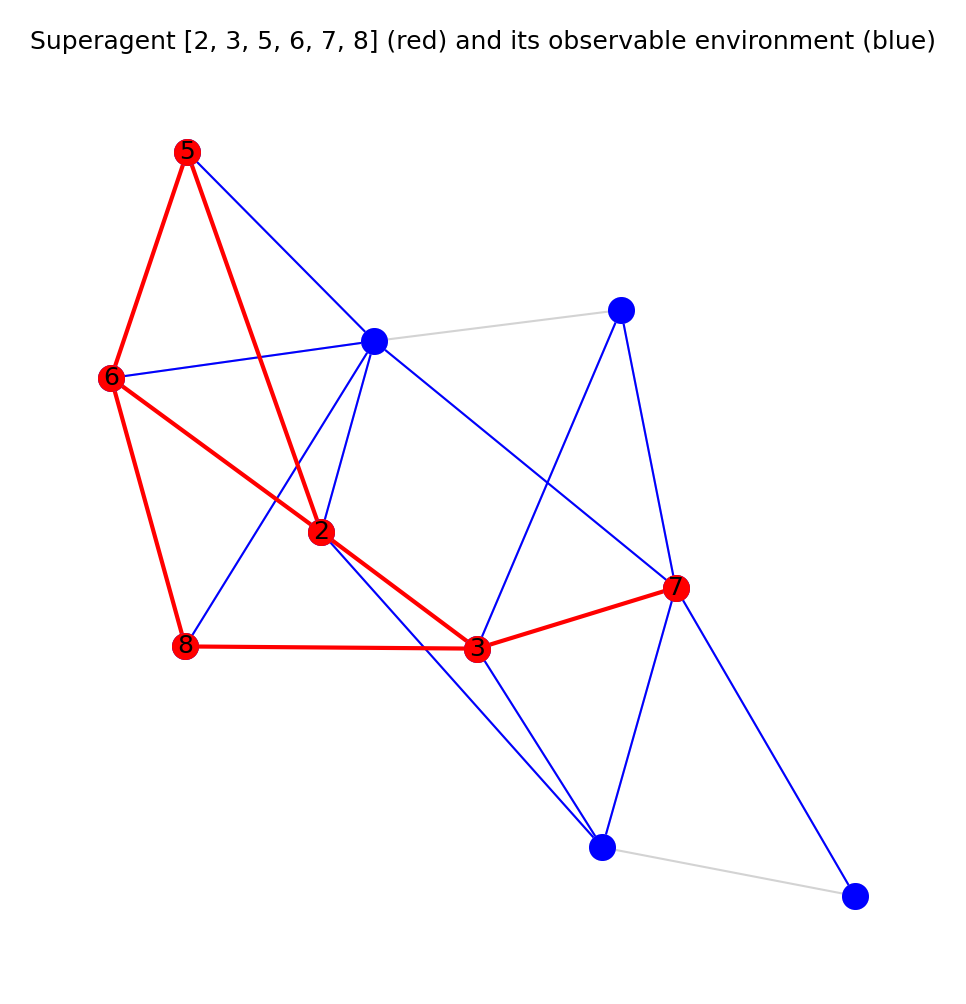

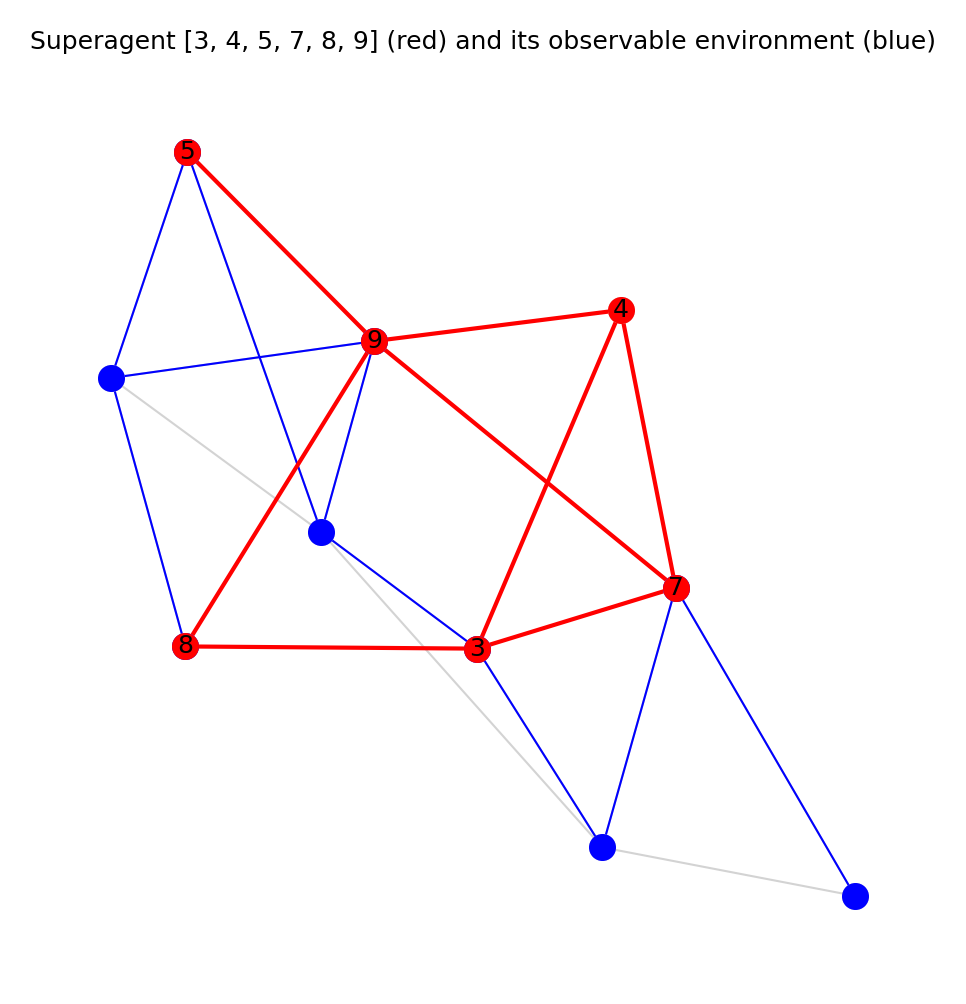

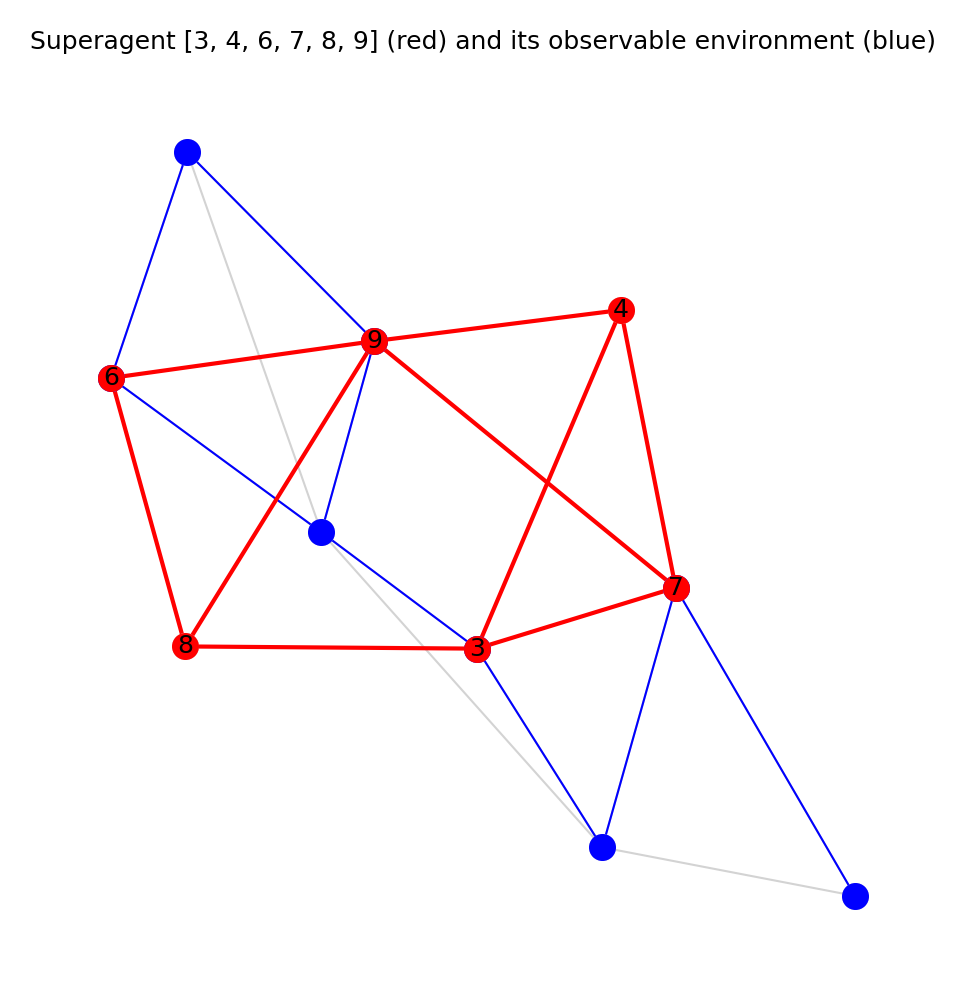

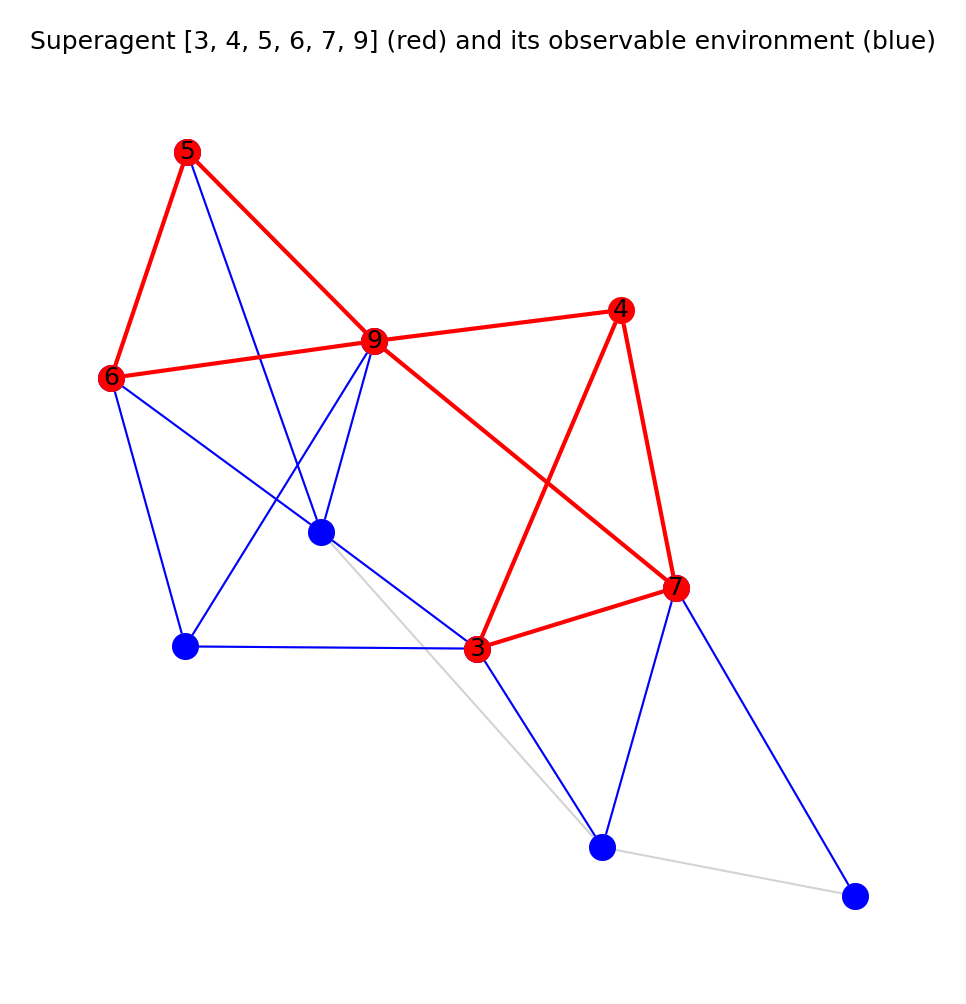

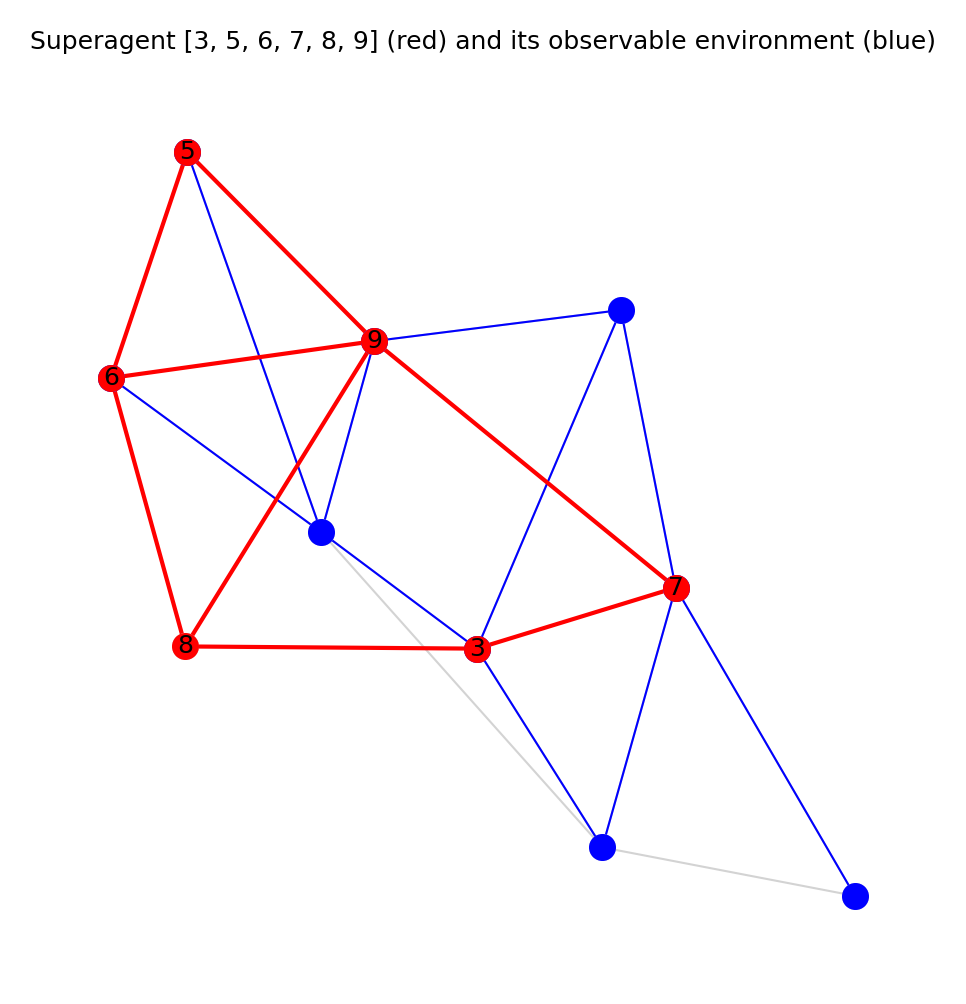

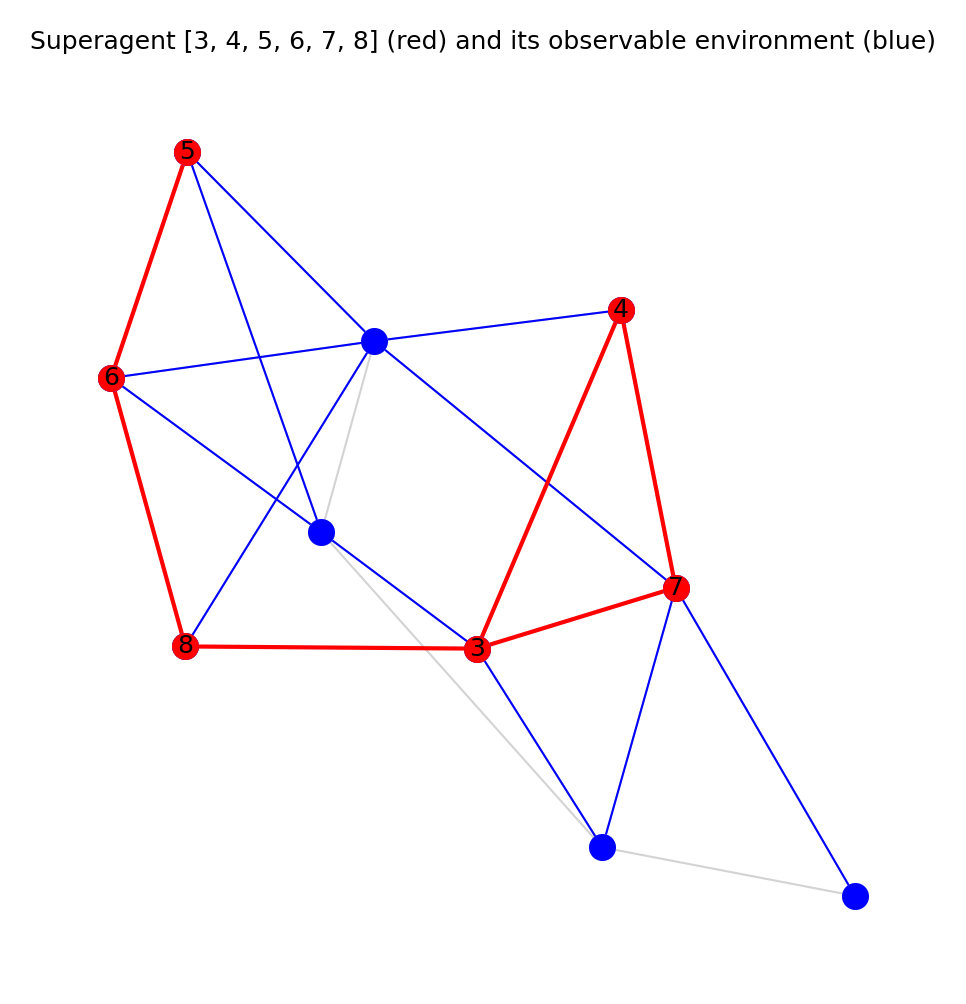

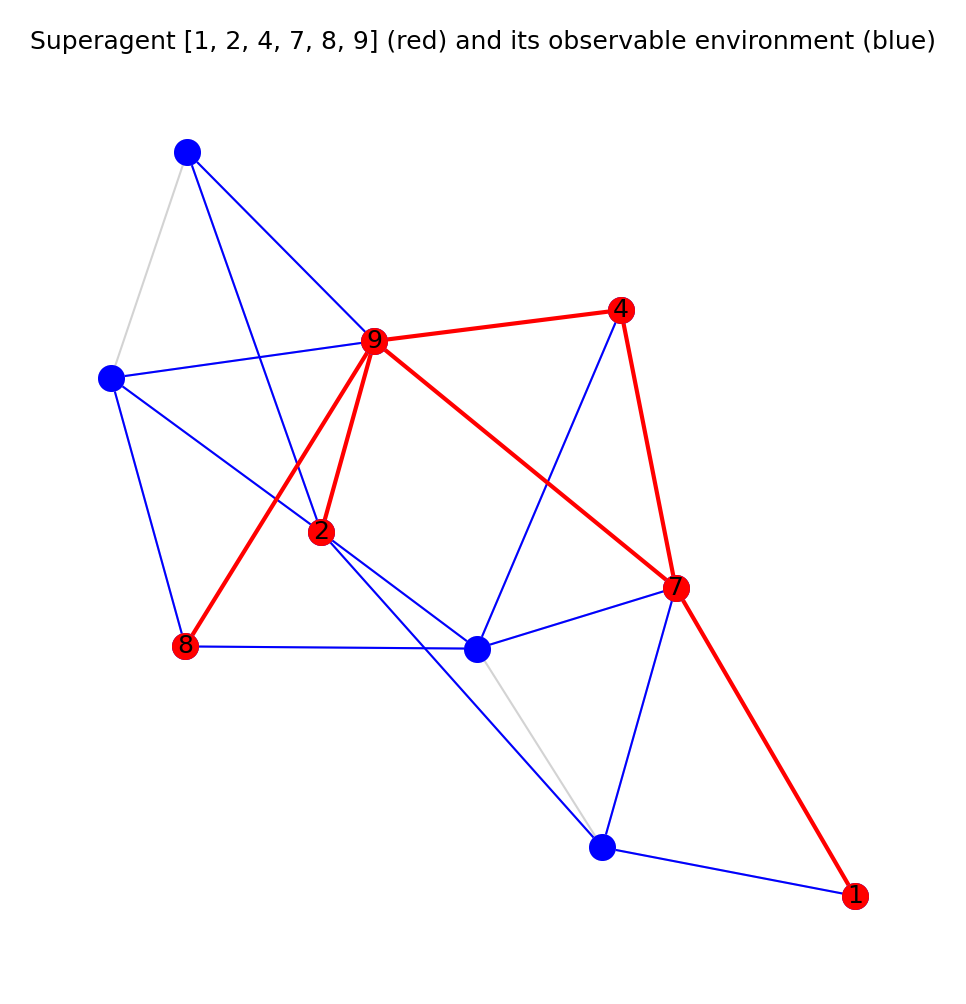

In [18]:
# superagent_idx = 50
# superagent = superagents[superagent_idx]
for superagent in superagents[440:450]:
    superagent_graph = superagent
    environment_graph, blanket_graph, boundary_subgraph = get_environment_and_blanket_graphs(G, superagent_graph)
    plot_superagent_graph(
        G, 
        pos, 
        superagent_graph=superagent_graph, 
        # blanket_graph=blanket_graph, 
        boundary_subgraph=boundary_subgraph
    )

In [302]:
# nx.draw(
#     environment_graph,
#     {node: pos[node] for node in environment_graph.nodes},
#     with_labels=True,
#     node_size=30,
#     node_color='blue',
#     edge_color='lightgray',
#     width=1.0,
#     font_size=6
# )

In [19]:
def get_internal_and_env_timeseries(variables_history, superagent_graph, environment_graph):
    # Get the internal and environment timeseries
    S_timeseries = []
    E_timeseries = []
    for t in range(T):
        S_timeseries.append([])
        for i in superagent_graph.nodes:
            S_timeseries[t].append(variables_history['u'][t][i])
        E_timeseries.append([])
        for j in environment_graph.nodes:
            E_timeseries[t].append(variables_history['u'][t][j])

    S_timeseries = np.array(S_timeseries)
    E_timeseries = np.array(E_timeseries)
    return S_timeseries, E_timeseries

In [20]:
superagent_idx = 30
superagent = superagents[superagent_idx]

superagent_graph = superagent
environment_graph, blanket_graph, boundary_subgraph = get_environment_and_blanket_graphs(G, superagent_graph)
S_timeseries, E_timeseries = get_internal_and_env_timeseries(variables_history, superagent_graph, environment_graph)

print(f"Superagent {superagent.nodes}\n")
print(f'- S_timeseries {S_timeseries.shape}:')
print(S_timeseries[:10])
print(f'\n- E_timeseries {E_timeseries.shape}:')
print(E_timeseries[:10])

Superagent [6]

- S_timeseries (500, 1):
[[1]
 [0]
 [1]
 [0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]]

- E_timeseries (500, 4):
[[0 0 0 0]
 [1 1 0 1]
 [1 1 0 0]
 [1 1 1 0]
 [0 1 1 0]
 [0 0 1 0]
 [1 0 1 0]
 [0 1 1 0]
 [1 1 1 1]
 [1 0 1 1]]


In [21]:
all_partition_timeseries = []
for superagent in superagents:
    superagent_graph = superagent
    environment_graph, blanket_graph, boundary_subgraph = get_environment_and_blanket_graphs(G, superagent_graph)
    S_timeseries, E_timeseries = get_internal_and_env_timeseries(variables_history, superagent_graph, environment_graph)
    # if E_timeseries.shape[1] > 0:  # FIXME: this only happens when the superagent is the whole graph
    all_partition_timeseries.append((S_timeseries, E_timeseries))
print(f"All partition timeseries: {len(all_partition_timeseries)}")

All partition timeseries: 643


In [22]:
%store all_partition_timeseries

Stored 'all_partition_timeseries' (list)


## Superagent games

In [238]:
superagent_games = []
for superagent in superagents:
    games = [G.edges[edge]['game'] for edge in superagent.edges]
    game_names = [get_game_name(game, available_games) for game in games]
    superagent_games.append(game_names)

# Example: Print games for the first superagent
print(superagent_games[20:25])

[['Ch', 'Ch', 'SH'], ['Ch', 'Ch', 'SH', 'SH'], ['Ch', 'Ch', 'Ch', 'SH', 'SH', 'Ch'], [], []]


In [259]:
%store superagents

Stored 'superagents' (list)


## Synergistic coefficients (imported from other notebook)

In [23]:
%store -r all_synergistic_coefficients

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


1.2205388736903493


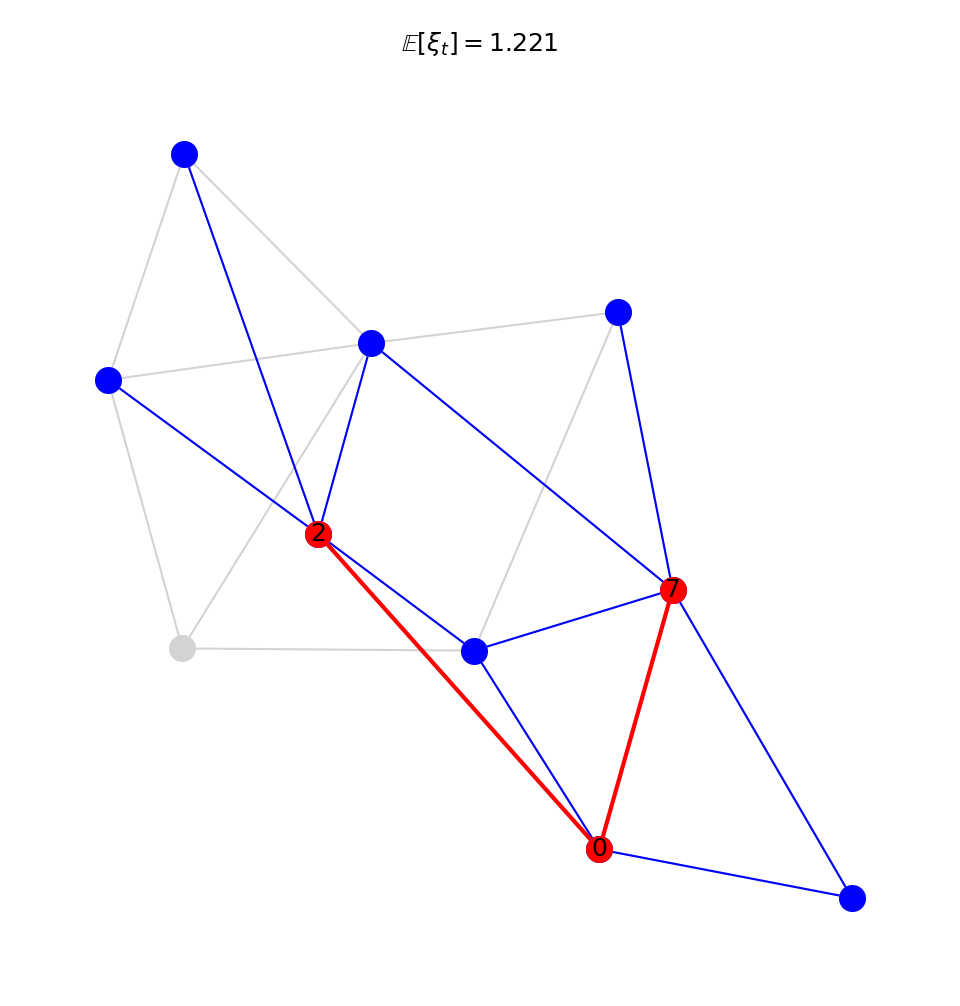

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


1.2462509517605609


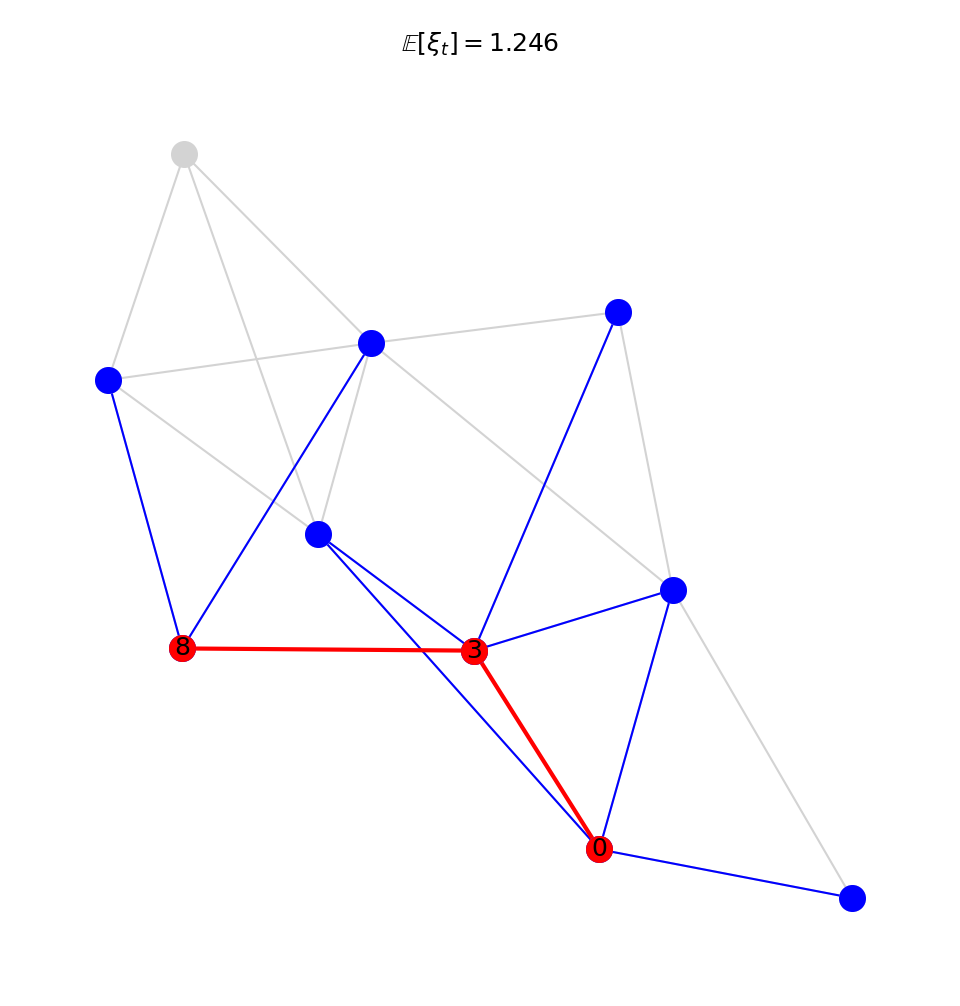

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


1.1802172839033052


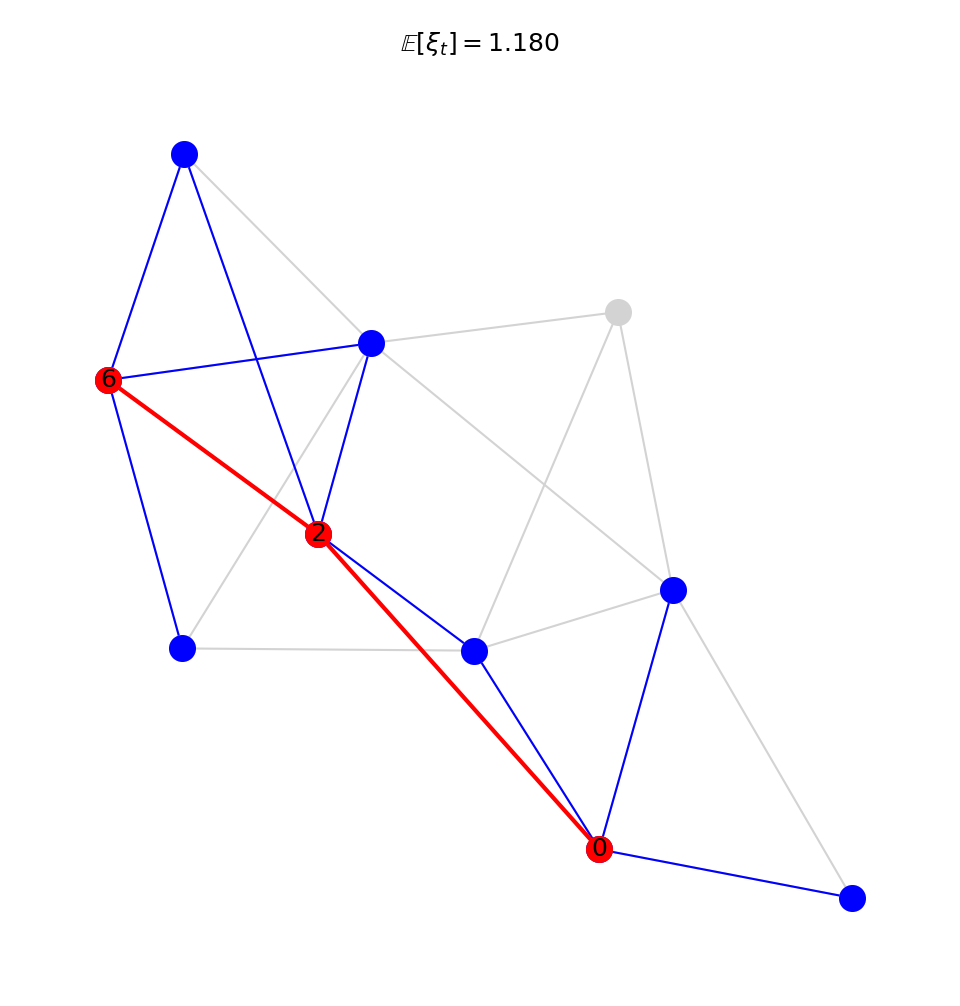

1.230870379719207


INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


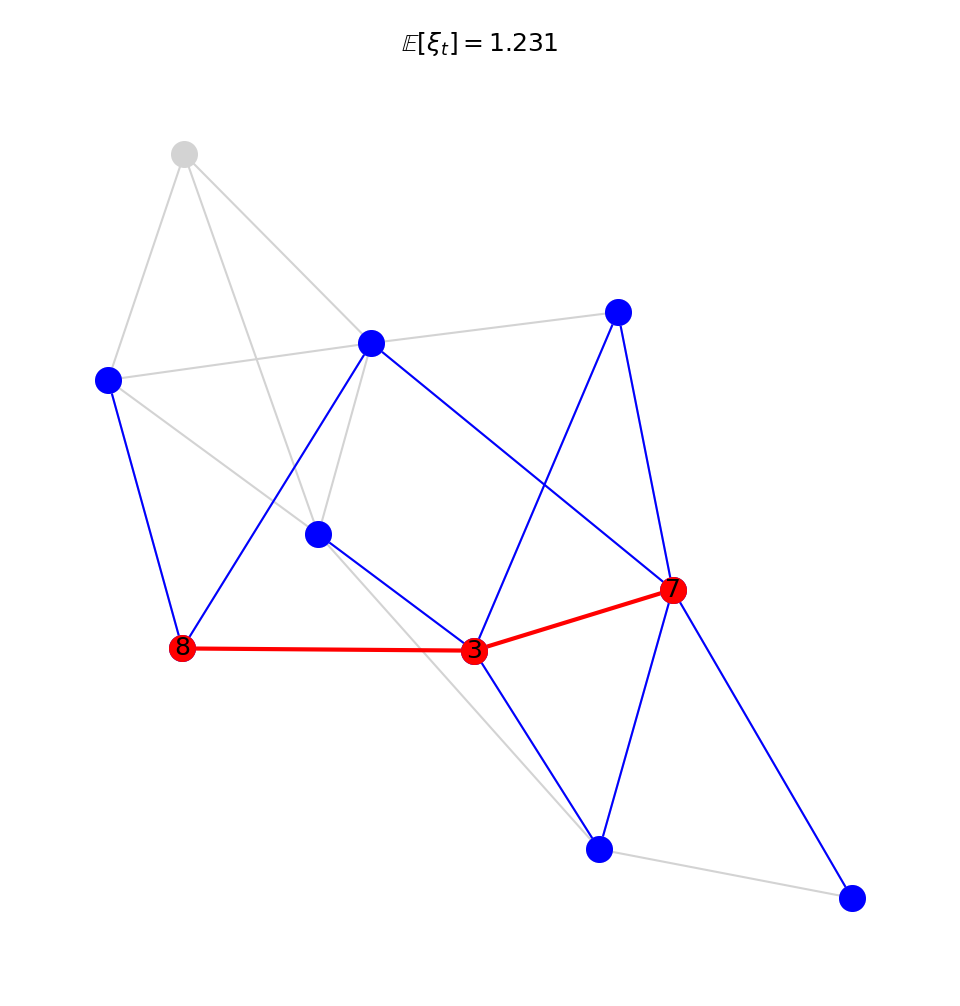

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


1.1317266781463966


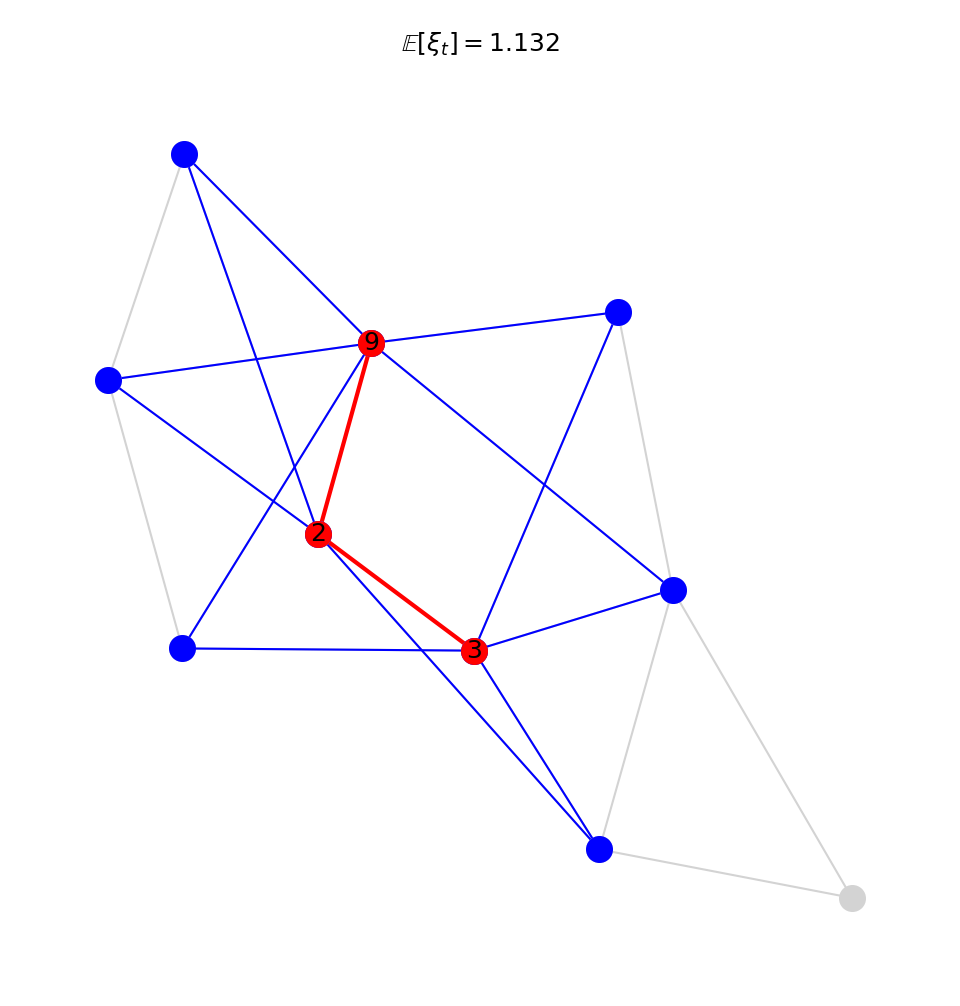

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


1.1142030856612197


INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


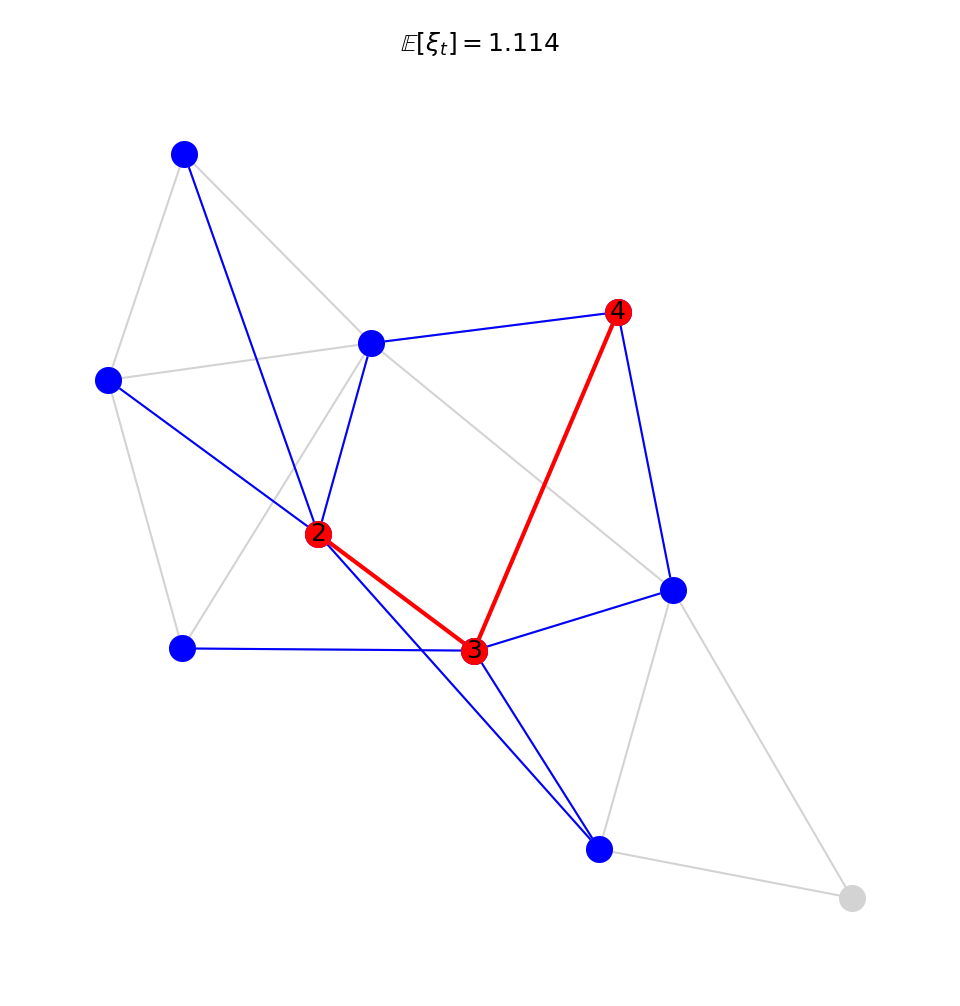

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


1.1745975713388344


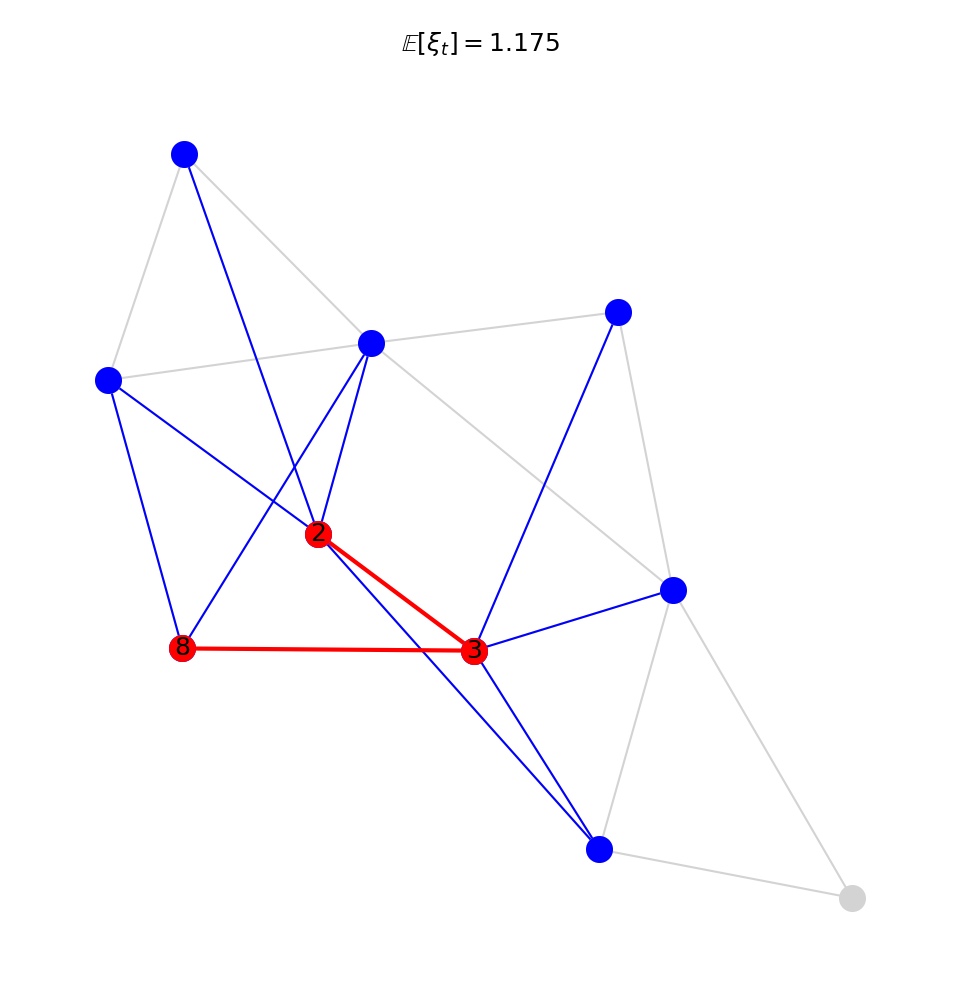

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


1.165391745020377


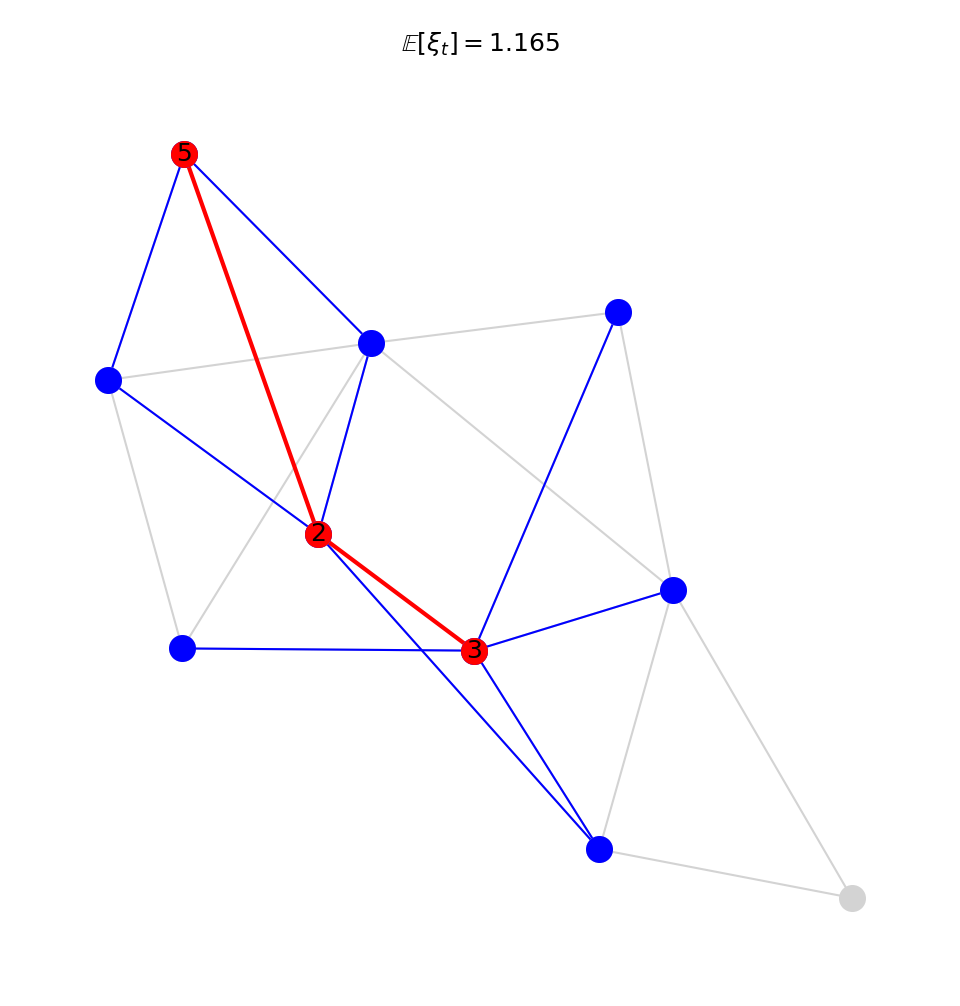

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


1.1449871555459354


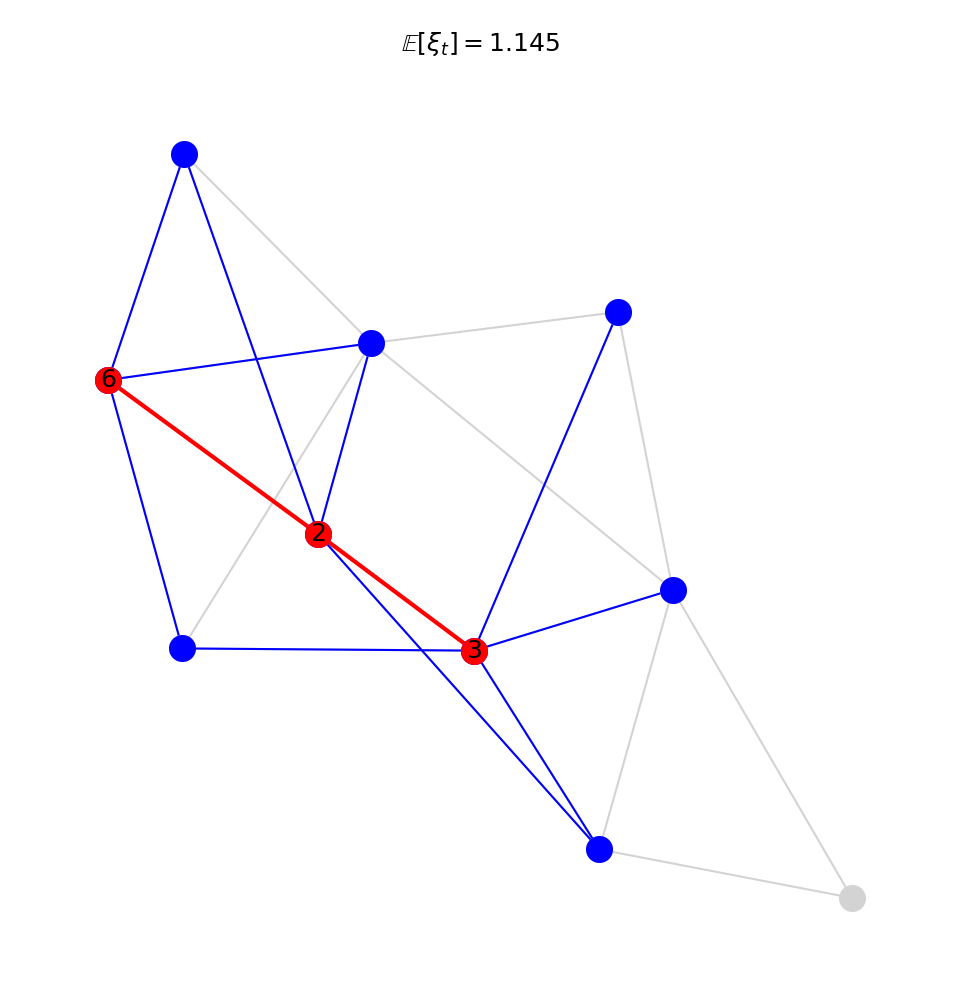

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


1.1279075931366271


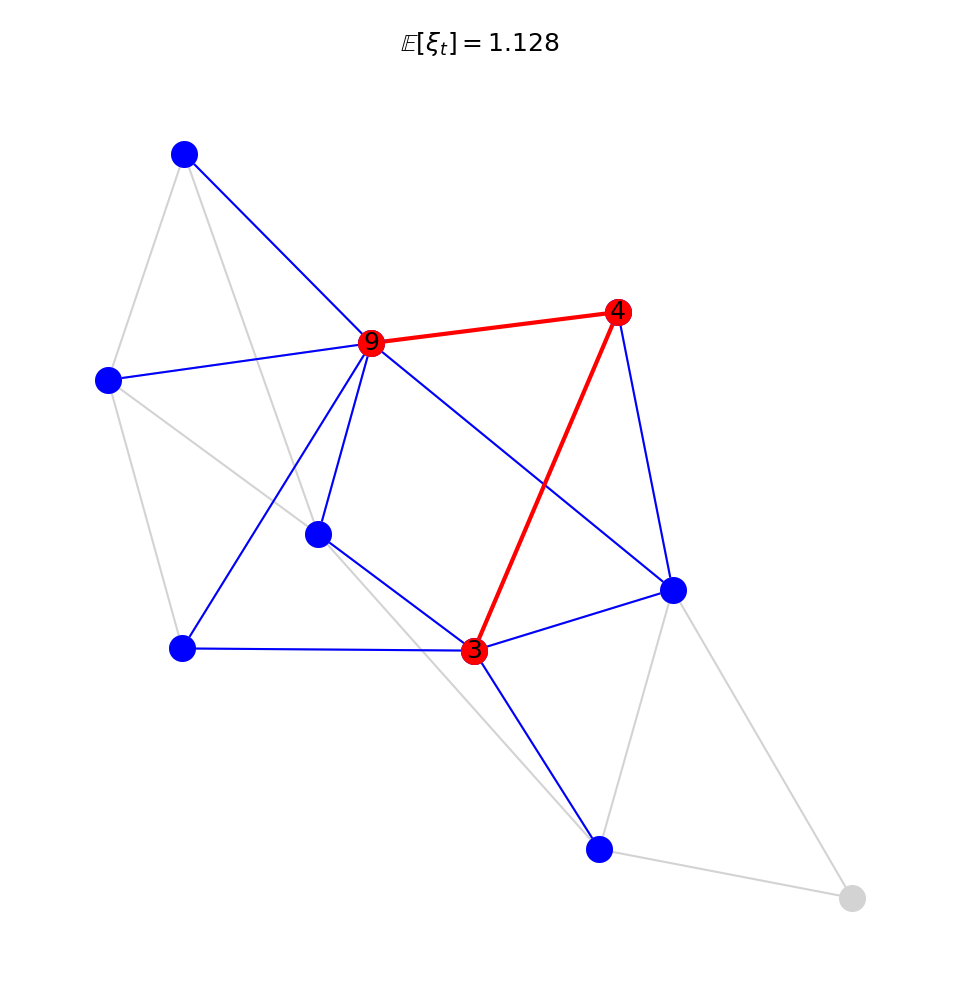

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


1.1510305671997962


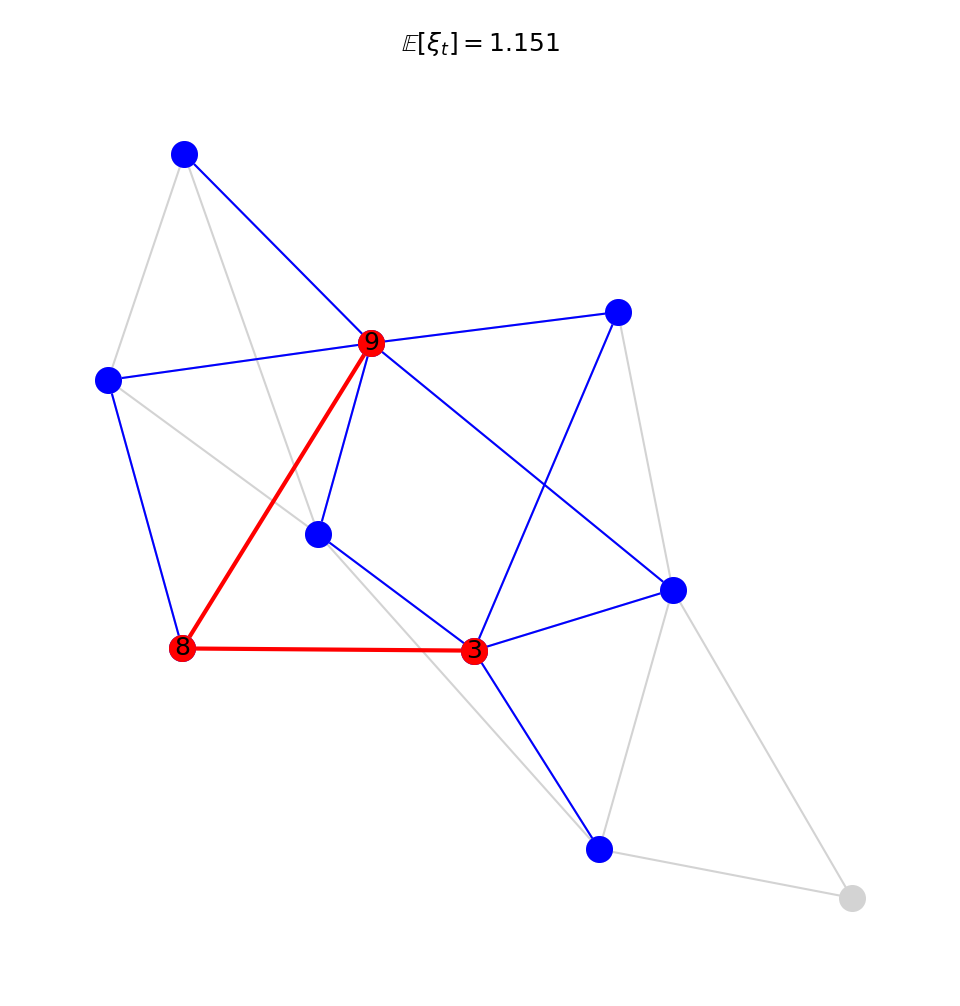

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


1.1624878222291029


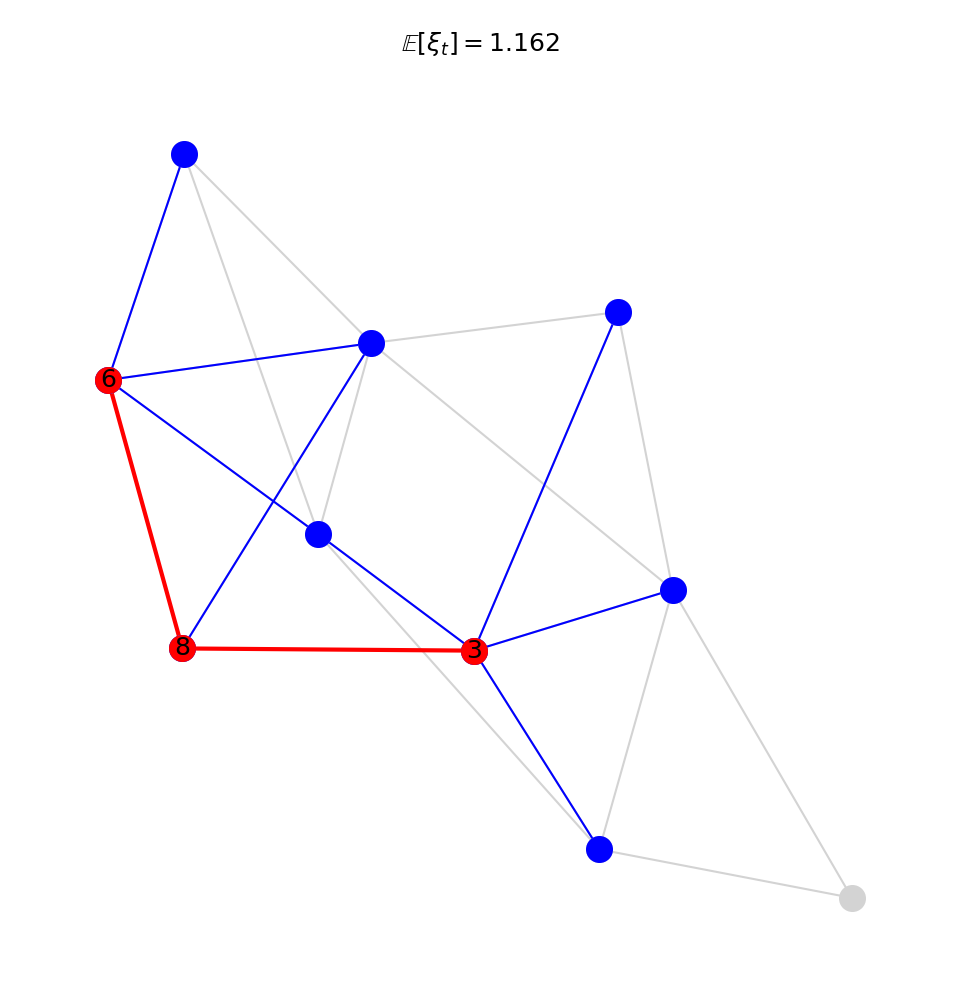

1.1305759498565895


INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


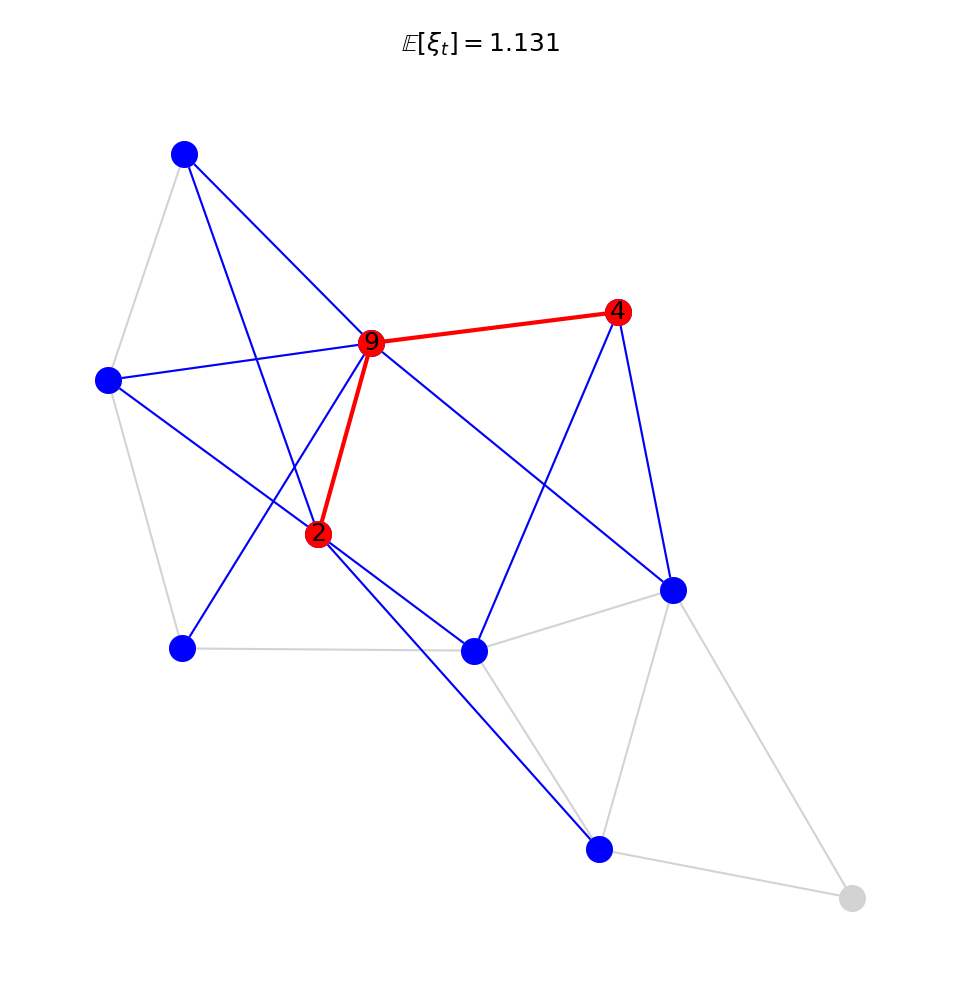

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


1.1078699038025321


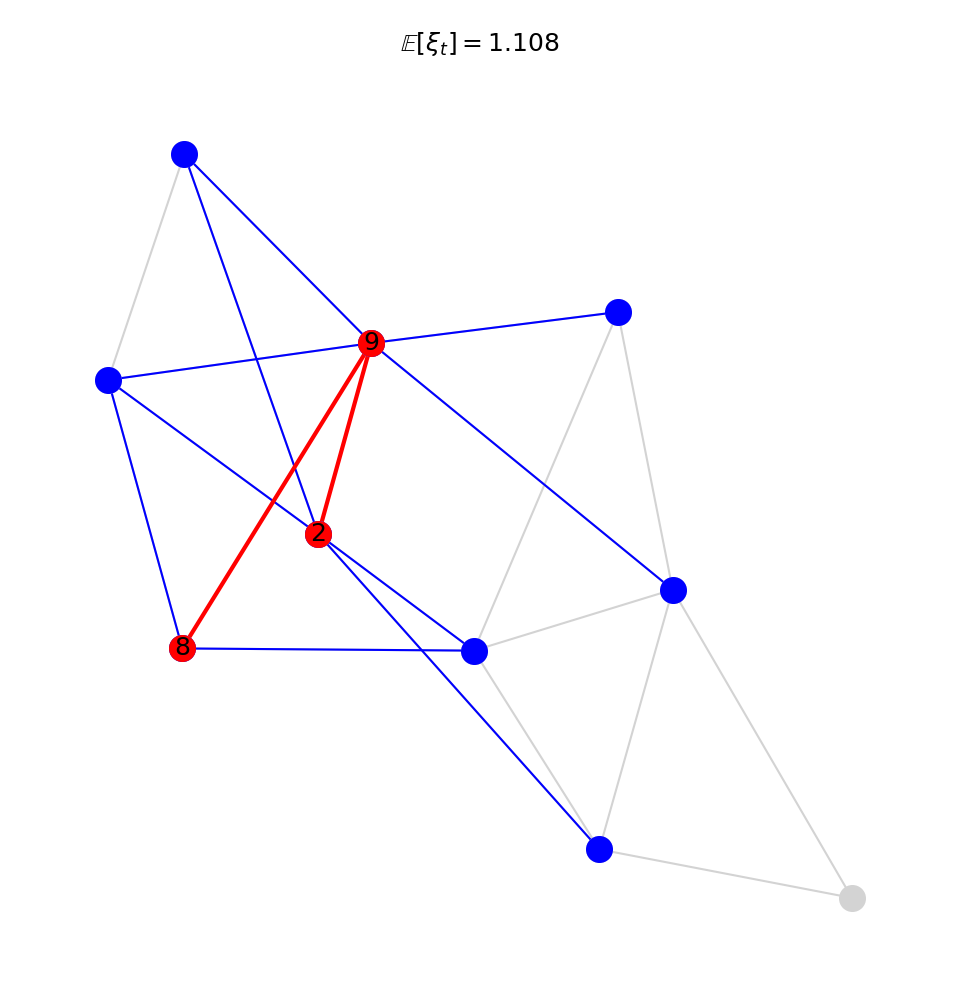

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


1.1864717543772534


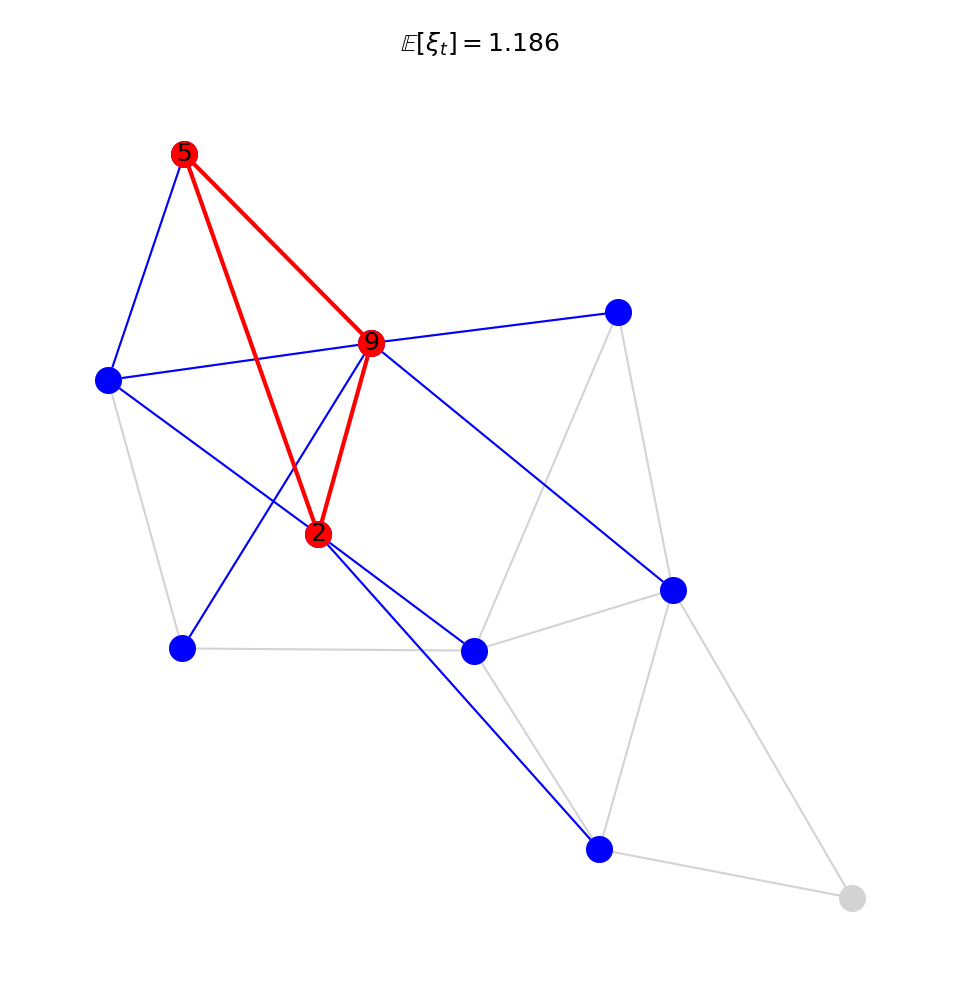

INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol E from STIXNonUnicode


1.1679016656045487


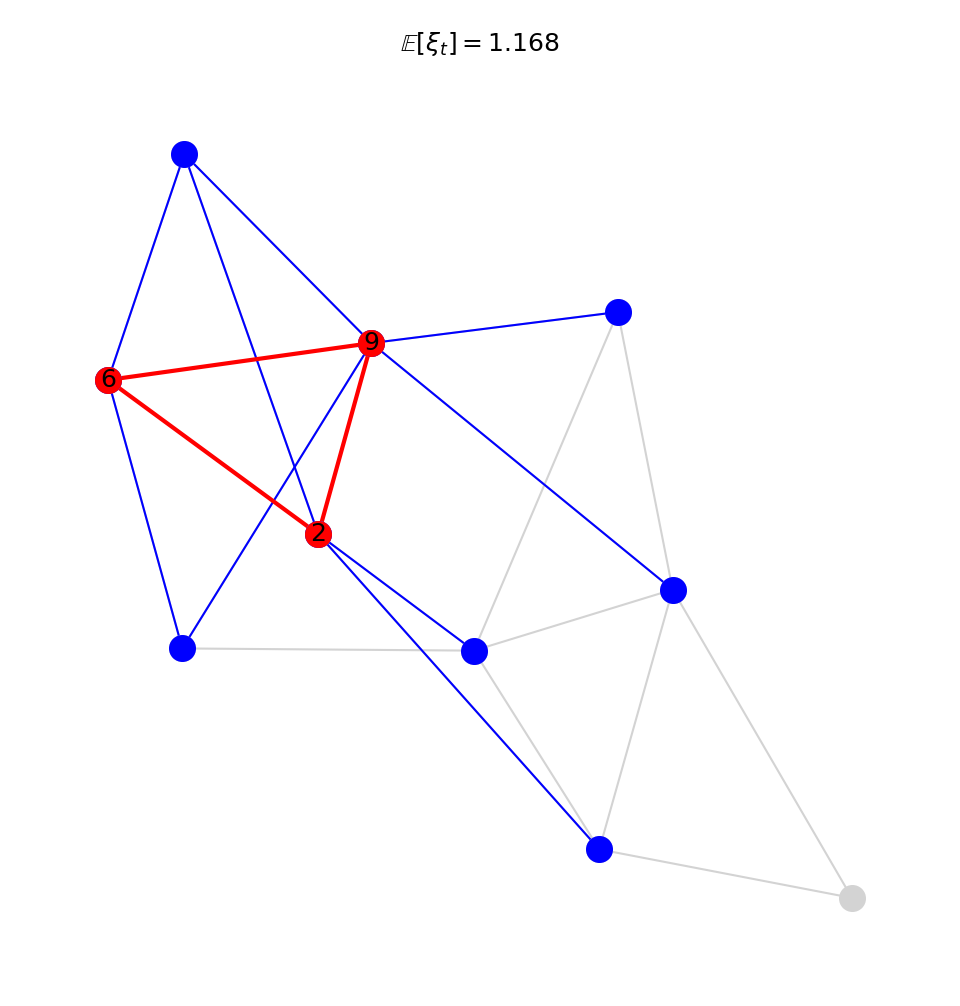

In [37]:
for selected_idx in np.where((all_synergistic_coefficients < 2) & (all_synergistic_coefficients > 1))[0]:
    superagent_graph = superagents[selected_idx]
    if len(superagent_graph.nodes) != 3:
        continue
    print(all_synergistic_coefficients[selected_idx])
    environment_graph, blanket_graph, boundary_subgraph = get_environment_and_blanket_graphs(G, superagent_graph)
    plot_superagent_graph(
        G, 
        pos, 
        superagent_graph=superagent_graph, 
        # blanket_graph=blanket_graph, 
        boundary_subgraph=boundary_subgraph,
        title=r"$\mathbb{E}[\xi_t] = $" + f'{all_synergistic_coefficients[selected_idx]:.3f}'
    )

### D-BaSS empowerment

In [40]:
%store -r all_empowerments

0.2899650900630146


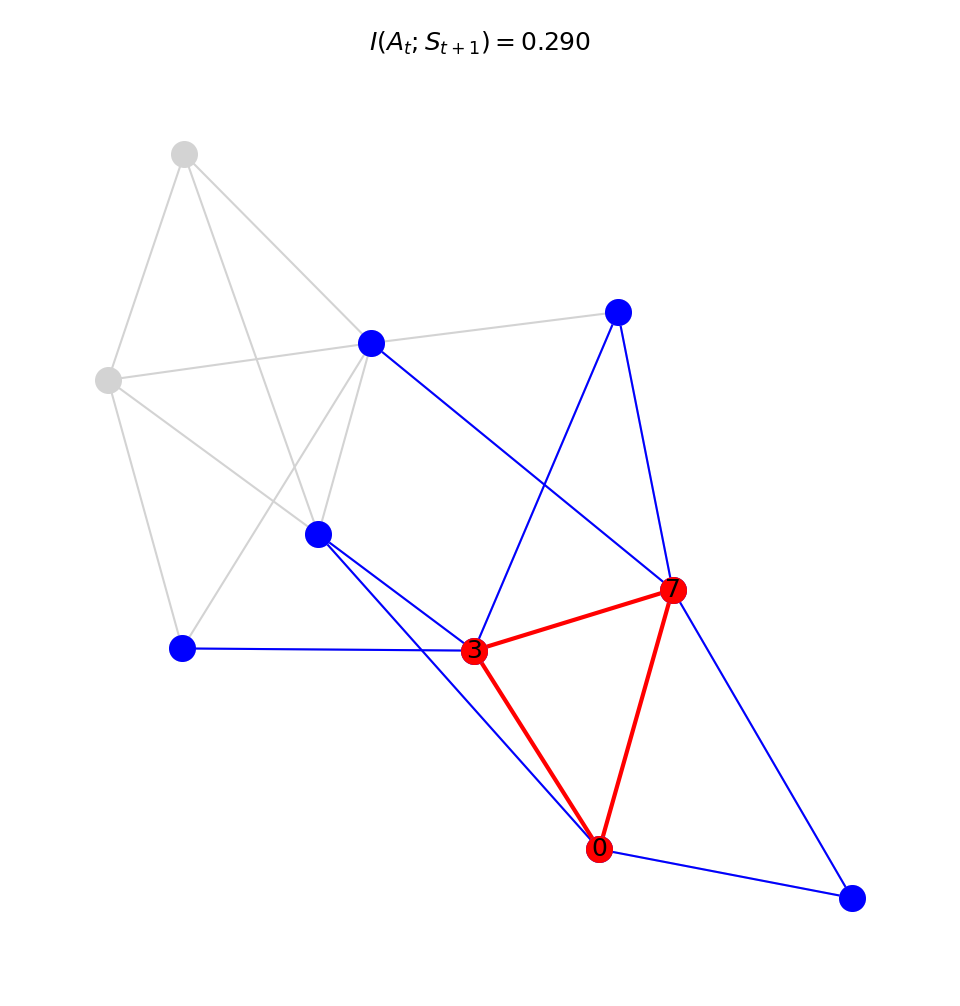

0.276742161740083


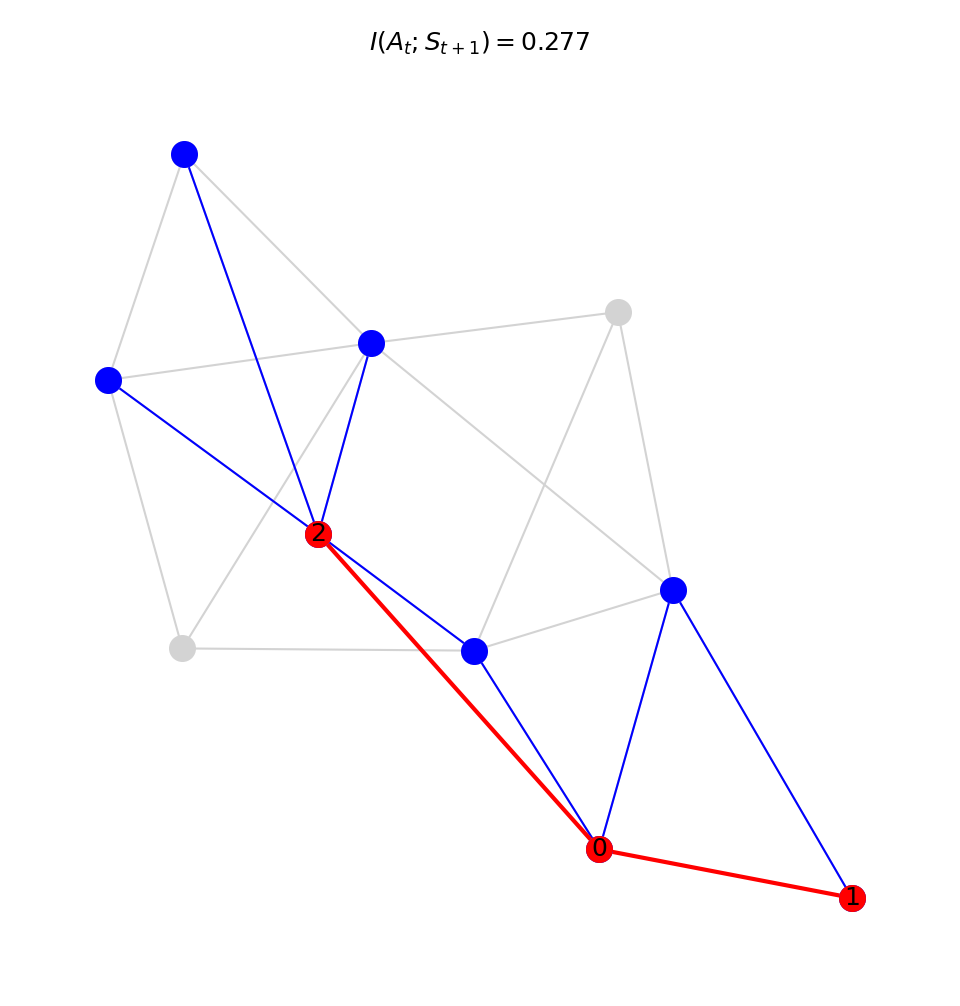

0.30487654735473224


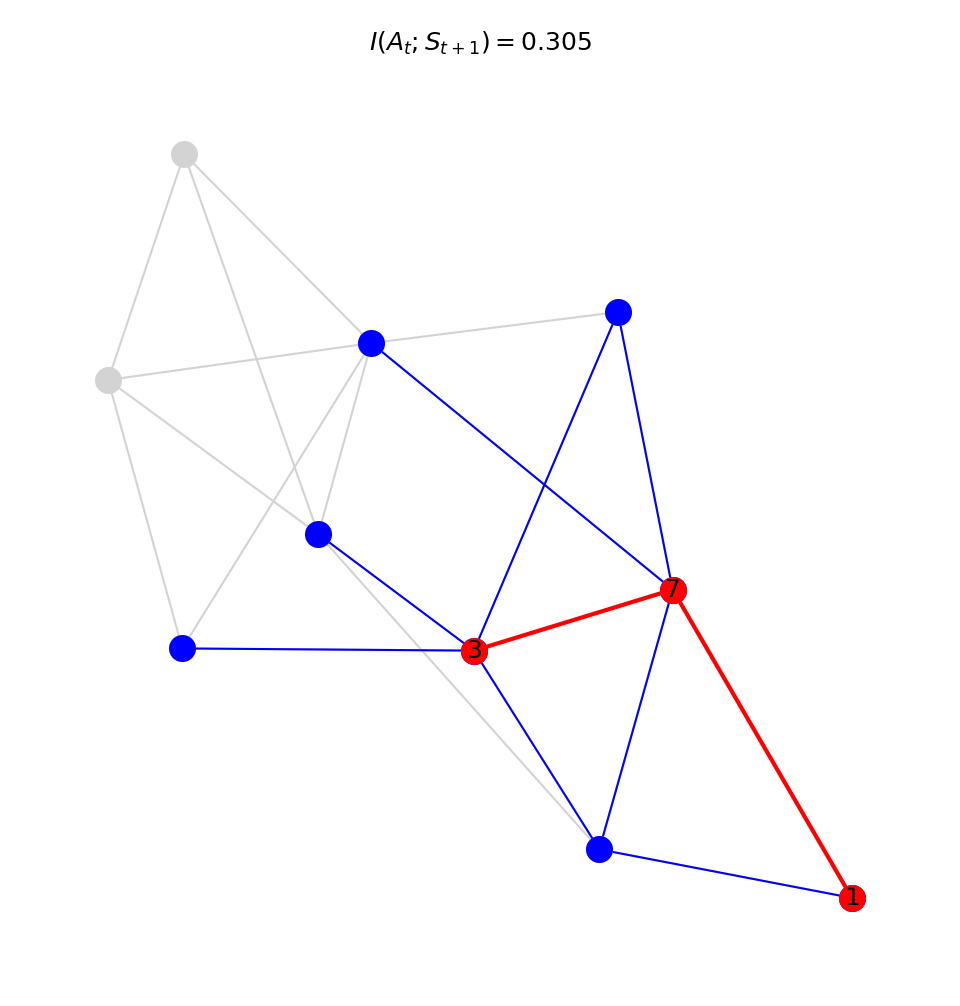

0.23807395676079118


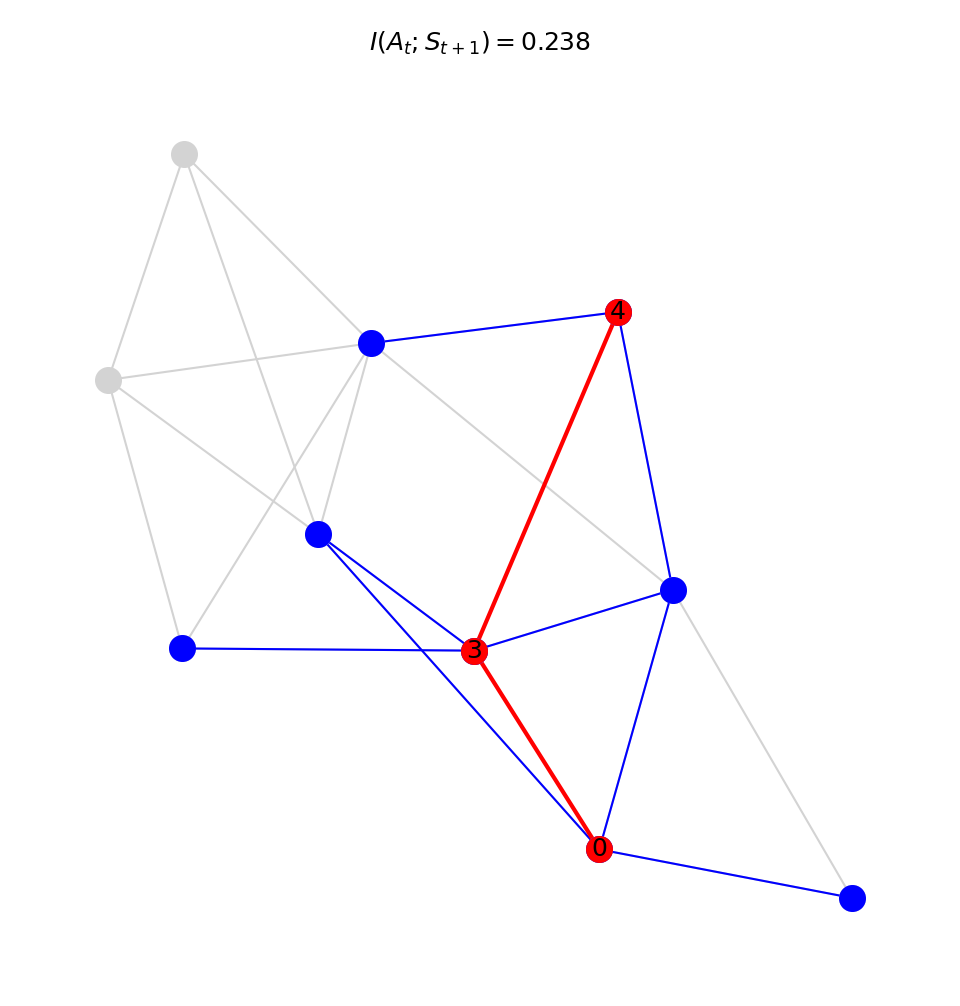

0.2606525991460867


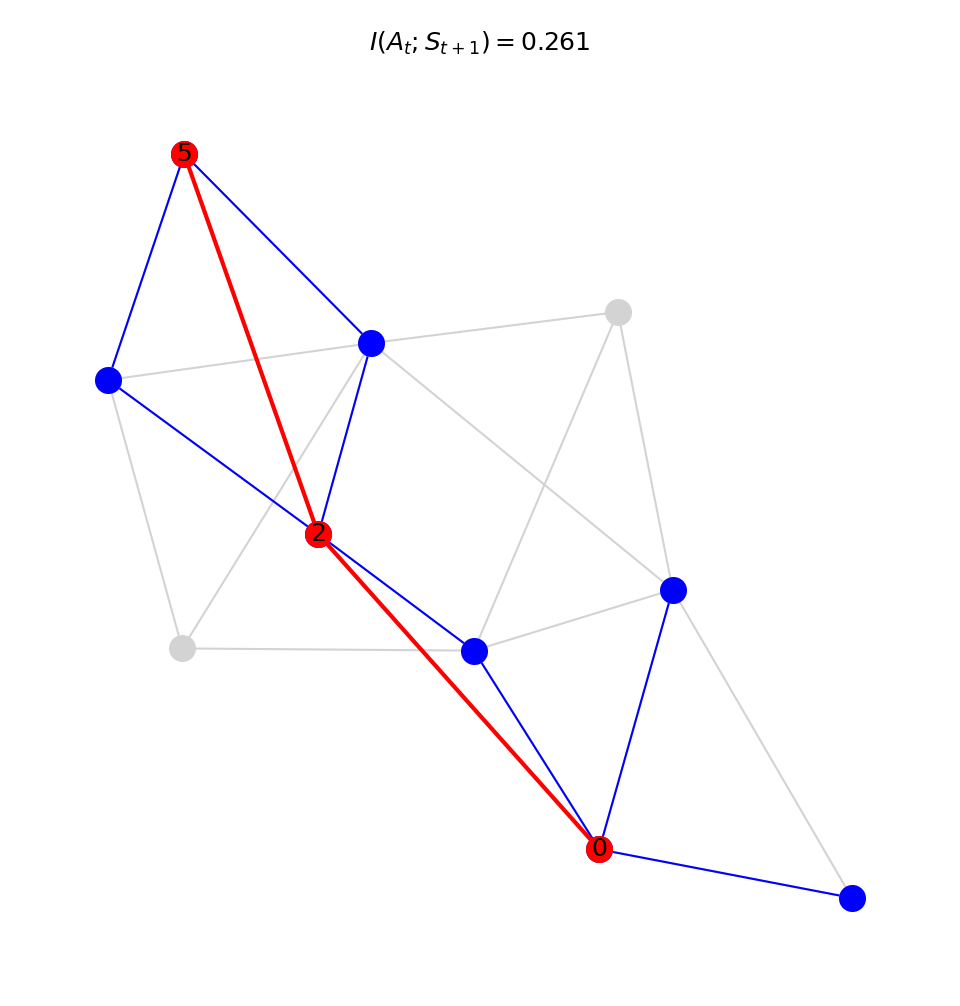

0.3429744553900705


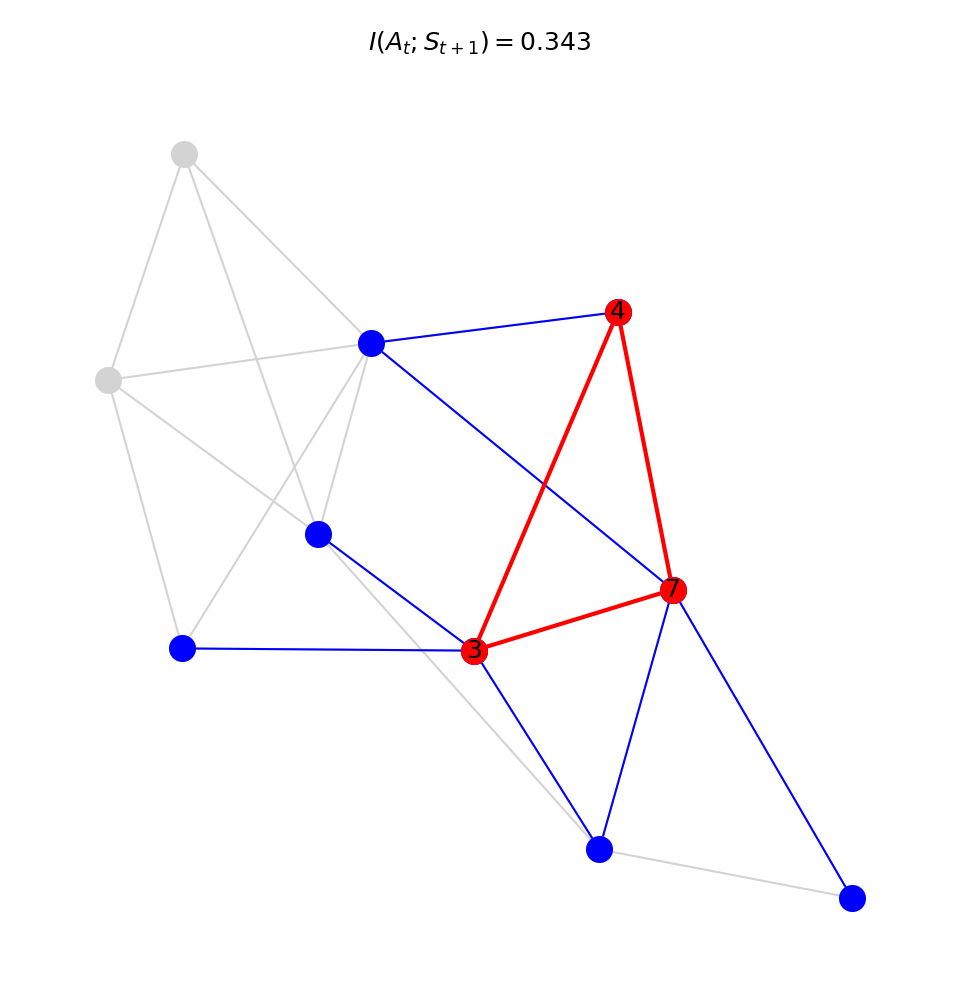

0.3196179745861925


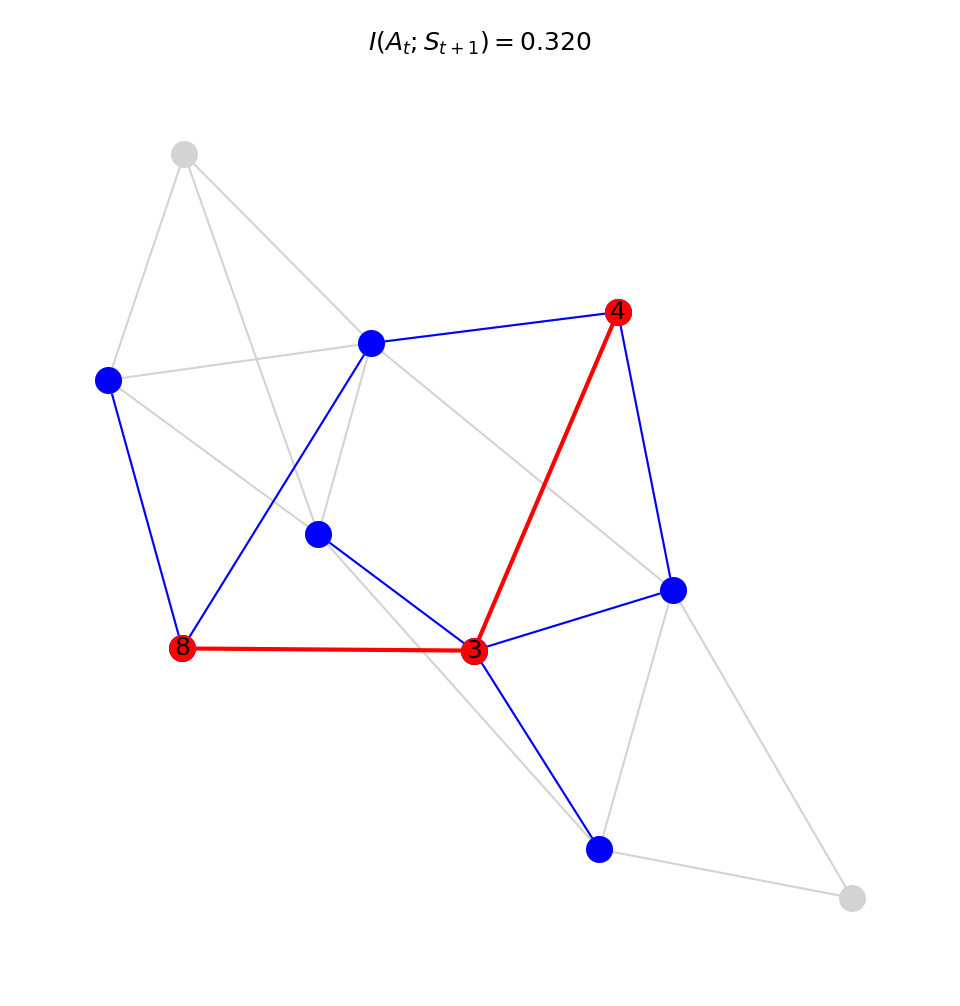

0.2163586900078858


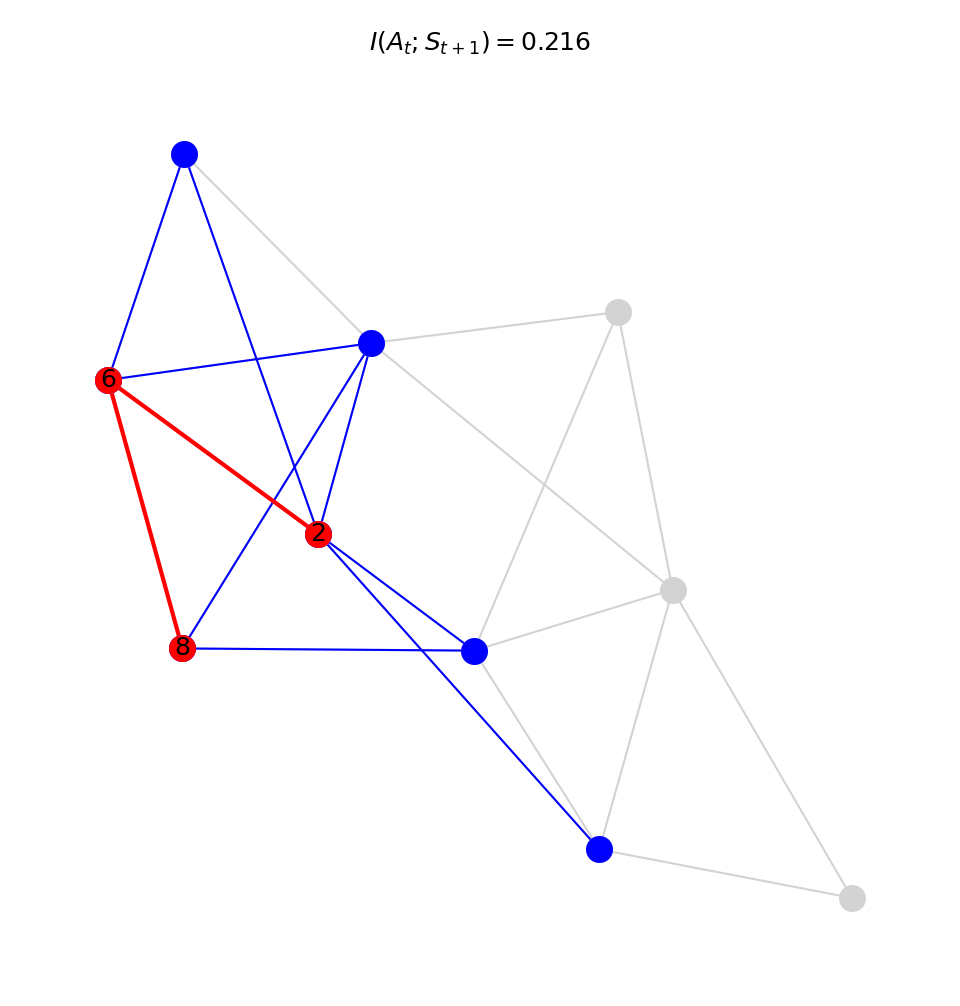

0.3601440691855124


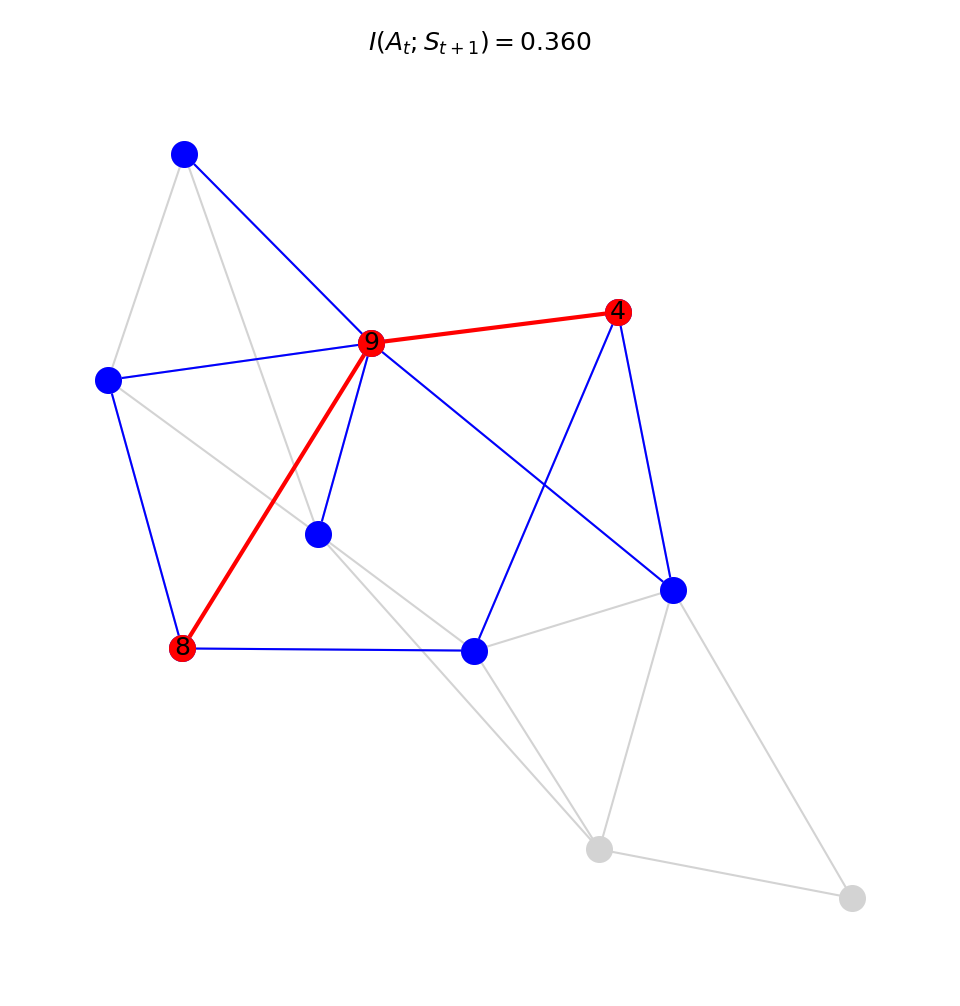

0.35387916791341967


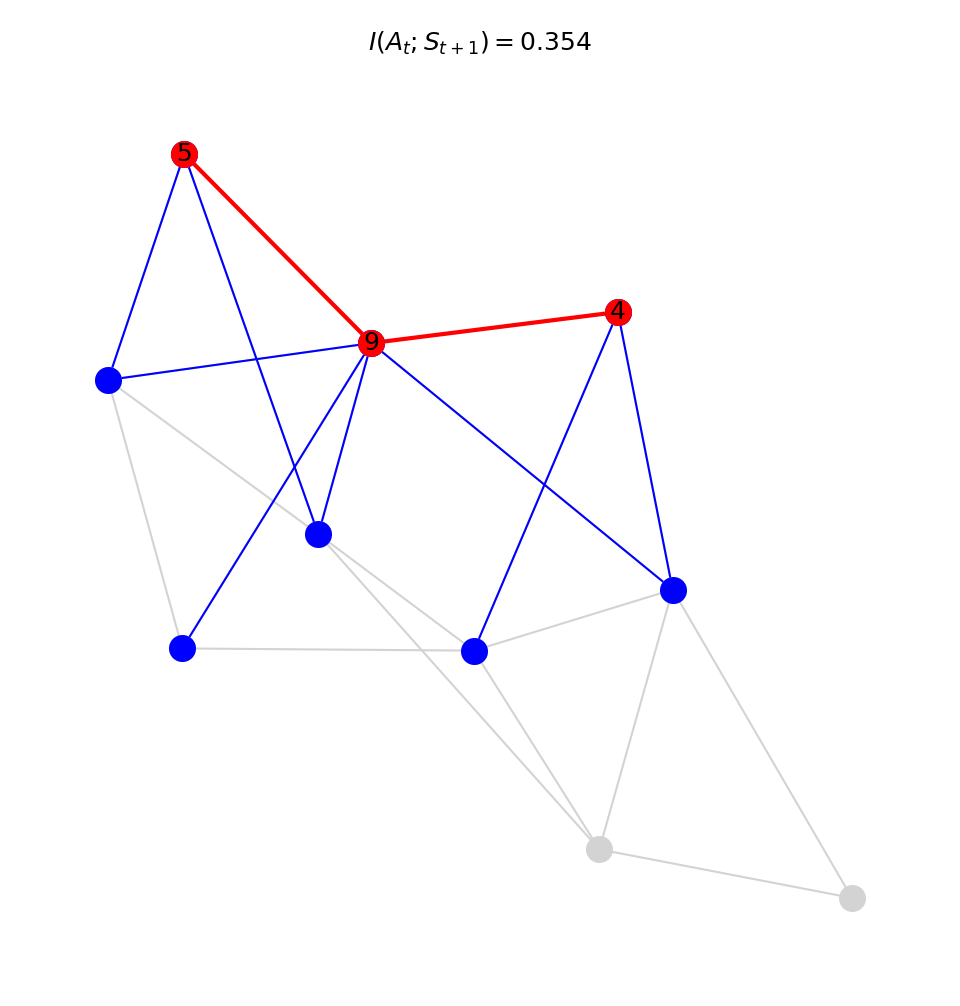

0.34504018755073457


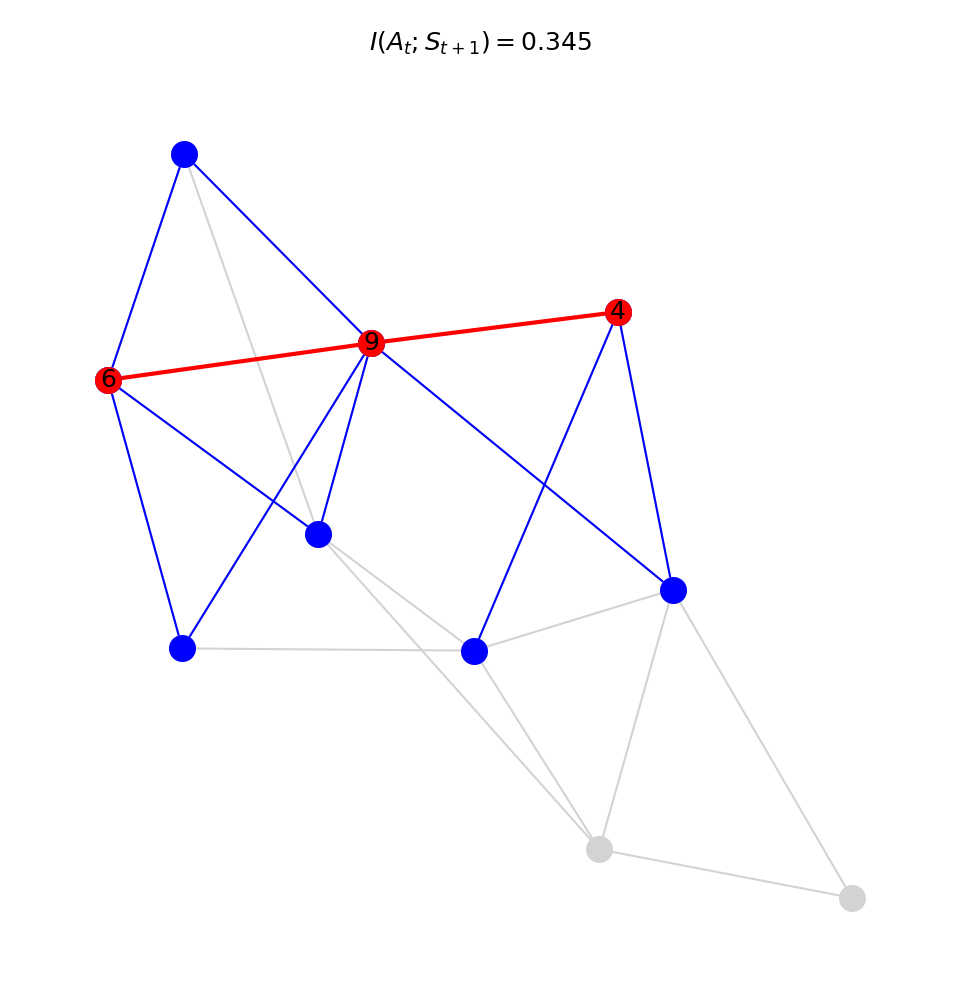

0.3952816142207622


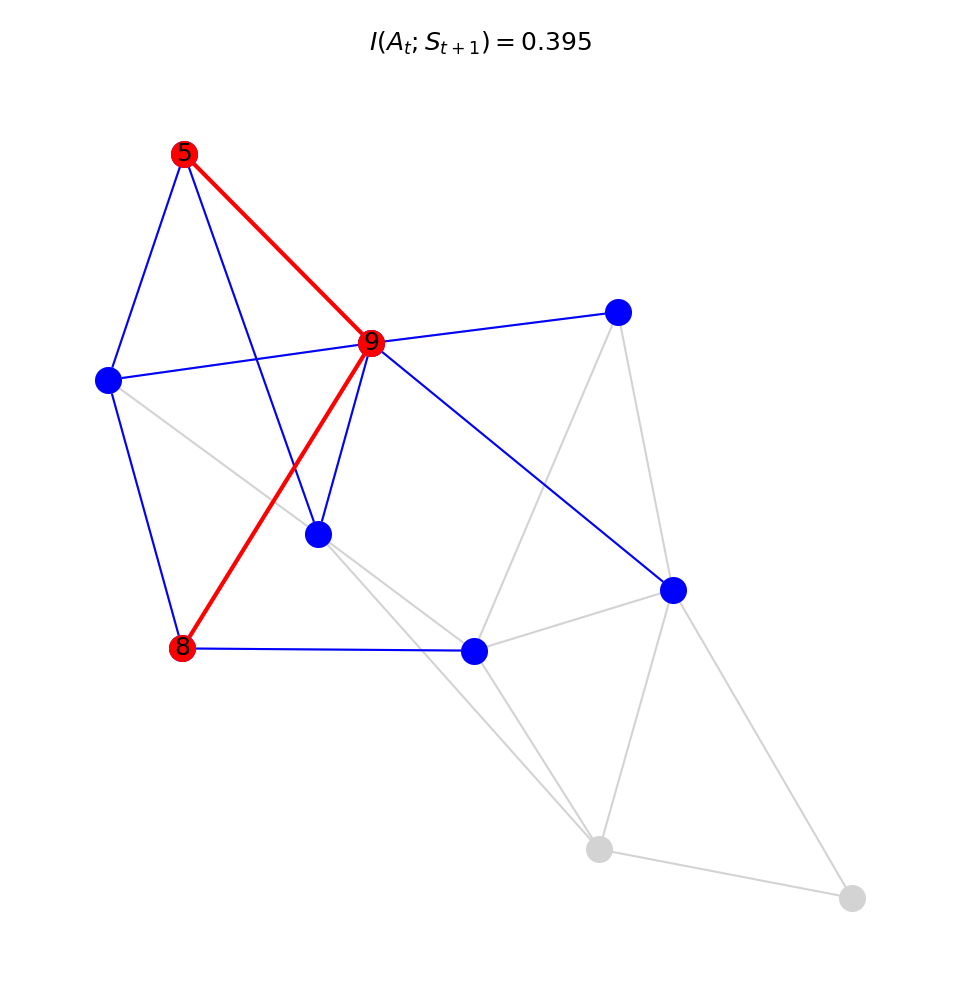

0.3396815973487043


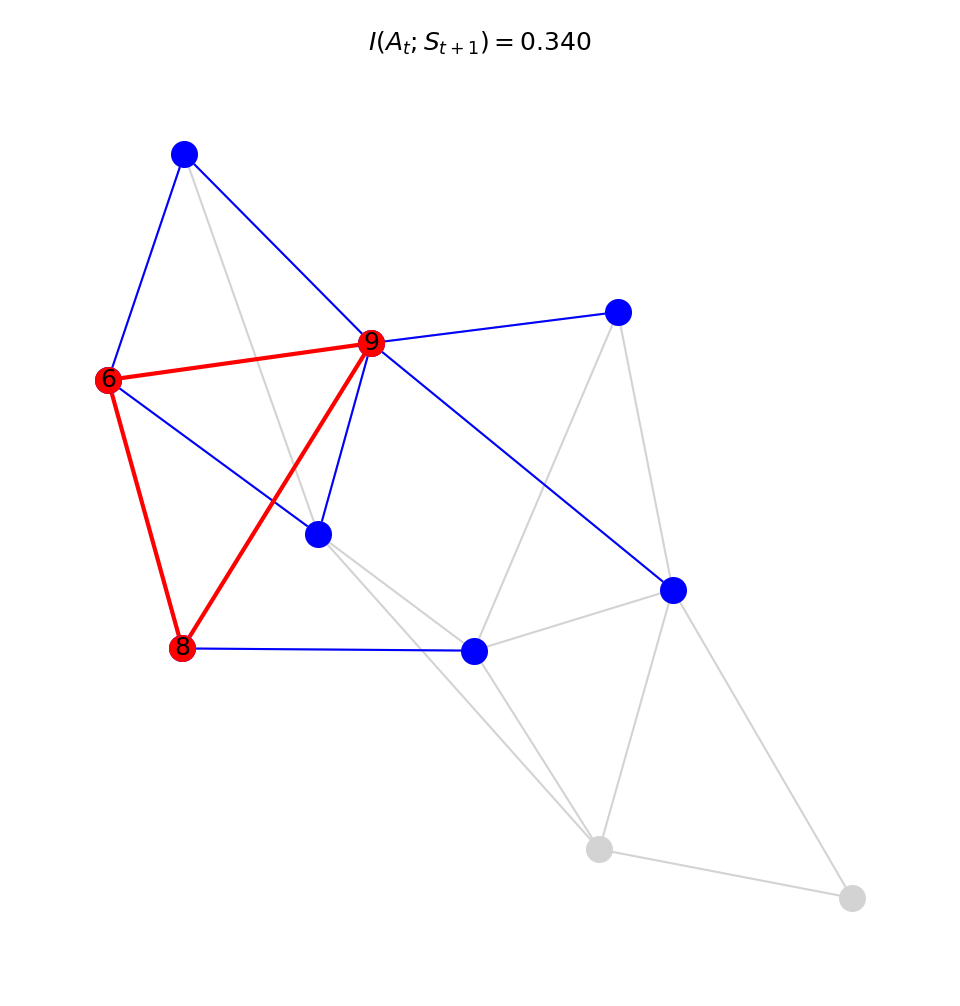

In [43]:
for selected_idx in np.where((all_empowerments < 0.4) & (all_empowerments > 0.2))[0]:
    superagent_graph = superagents[selected_idx]
    if len(superagent_graph.nodes) != 3:
        continue
    print(all_empowerments[selected_idx])
    environment_graph, blanket_graph, boundary_subgraph = get_environment_and_blanket_graphs(G, superagent_graph)
    plot_superagent_graph(
        G, 
        pos, 
        superagent_graph=superagent_graph, 
        # blanket_graph=blanket_graph, 
        boundary_subgraph=boundary_subgraph,
        title=r"$I(A_t; S_{t+1}) = $" + f'{all_empowerments[selected_idx]:.3f}'
    )